# M5 Forecasting Accuracy - Data Understanding

## Objective

The goal of this project is to understand the M5 Forecasting dataset and build a forecasting model capable of predicting the next 28 days of product demand.

This notebook focuses on understanding the datasets before performing any analysis or modeling.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
calendar = pd.read_csv("../data/raw/calendar.csv")
sales = pd.read_csv("../data/raw/sales_train_validation.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")
submission = pd.read_csv("../data/raw/sample_submission.csv")

In [6]:
datasets = {
    "Calendar": calendar,
    "Sales": sales,
    "Prices": prices,
    "Submission": submission
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Calendar: (1969, 14)
Sales: (30490, 1919)
Prices: (6841121, 4)
Submission: (60980, 29)


In [7]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print(df.columns.tolist())


Calendar
--------------------------------------------------
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales
--------------------------------------------------
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_8

In [8]:
product_sales = sales.iloc[0, 6:]

print("Total Sales :", product_sales.sum())
print("Average Sales :", round(product_sales.mean(), 3))
print("Maximum Sales :", product_sales.max())
print("Zero Sales Days :", (product_sales == 0).sum())

Total Sales : 600
Average Sales : 0.314
Maximum Sales : 5
Zero Sales Days : 1492


In [9]:
# Number of unique products
sales['item_id'].nunique()

3049

In [10]:
# Number of stores
sales['store_id'].nunique()

10

In [11]:
# Number of categories
sales['cat_id'].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

## Business Question

How are Walmart's products distributed across major product categories?

In [12]:
category_counts = sales["cat_id"].value_counts()

category_counts

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

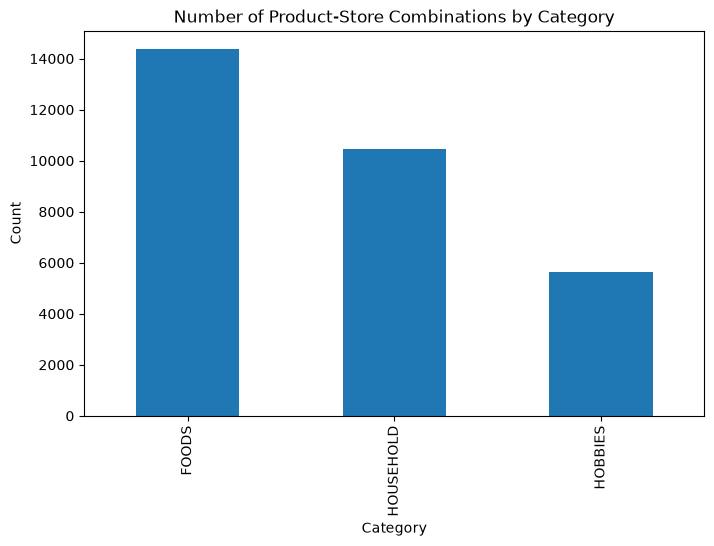

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_counts.plot(kind="bar")

plt.title("Number of Product-Store Combinations by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

### Insights

- Foods account for the largest share of products.
- Household products are the second-largest category.
- Hobbies contains the fewest products.
- The distribution suggests Walmart's inventory is heavily focused on food items.

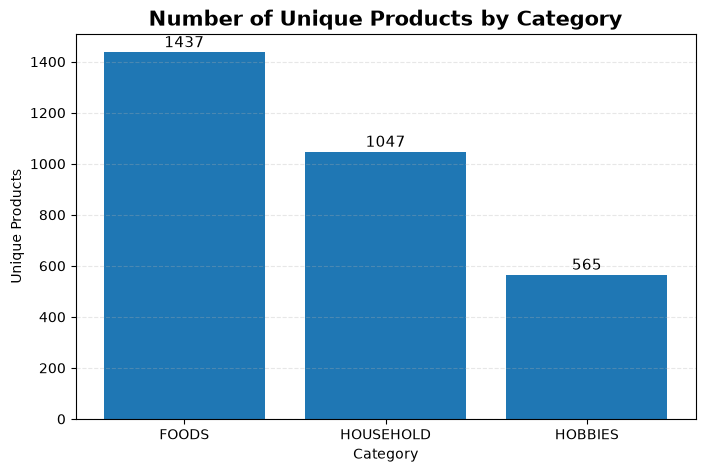

In [14]:
import matplotlib.pyplot as plt

# Count unique products in each category
category_products = (
    sales.groupby("cat_id")["item_id"]
         .nunique()
         .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    category_products.index,
    category_products.values
)

plt.title("Number of Unique Products by Category", fontsize=15, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Unique Products")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

### Insights

- Food products dominate Walmart's product assortment with 1,437 unique items.
- Household products account for 1,047 unique items.
- Hobbies contain only 565 products, making it the smallest category.
- The product portfolio is heavily skewed toward food items, reflecting Walmart's focus on grocery retail.

## Business Question

How have Walmart's total daily sales changed over time?

In [15]:
day_columns = [col for col in sales.columns if col.startswith("d_")]

len(day_columns)

1913

In [16]:
[col for col in sales.columns if col.startswith("d_")]

['d_1',
 'd_2',
 'd_3',
 'd_4',
 'd_5',
 'd_6',
 'd_7',
 'd_8',
 'd_9',
 'd_10',
 'd_11',
 'd_12',
 'd_13',
 'd_14',
 'd_15',
 'd_16',
 'd_17',
 'd_18',
 'd_19',
 'd_20',
 'd_21',
 'd_22',
 'd_23',
 'd_24',
 'd_25',
 'd_26',
 'd_27',
 'd_28',
 'd_29',
 'd_30',
 'd_31',
 'd_32',
 'd_33',
 'd_34',
 'd_35',
 'd_36',
 'd_37',
 'd_38',
 'd_39',
 'd_40',
 'd_41',
 'd_42',
 'd_43',
 'd_44',
 'd_45',
 'd_46',
 'd_47',
 'd_48',
 'd_49',
 'd_50',
 'd_51',
 'd_52',
 'd_53',
 'd_54',
 'd_55',
 'd_56',
 'd_57',
 'd_58',
 'd_59',
 'd_60',
 'd_61',
 'd_62',
 'd_63',
 'd_64',
 'd_65',
 'd_66',
 'd_67',
 'd_68',
 'd_69',
 'd_70',
 'd_71',
 'd_72',
 'd_73',
 'd_74',
 'd_75',
 'd_76',
 'd_77',
 'd_78',
 'd_79',
 'd_80',
 'd_81',
 'd_82',
 'd_83',
 'd_84',
 'd_85',
 'd_86',
 'd_87',
 'd_88',
 'd_89',
 'd_90',
 'd_91',
 'd_92',
 'd_93',
 'd_94',
 'd_95',
 'd_96',
 'd_97',
 'd_98',
 'd_99',
 'd_100',
 'd_101',
 'd_102',
 'd_103',
 'd_104',
 'd_105',
 'd_106',
 'd_107',
 'd_108',
 'd_109',
 'd_110',
 'd_111'

In [17]:
daily_sales = sales[day_columns].sum()

In [18]:
daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

In [19]:
daily_sales.describe()

count     1913.000000
mean     34341.562467
std       7345.905196
min         11.000000
25%      29654.000000
50%      33732.000000
75%      38689.000000
max      57218.000000
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

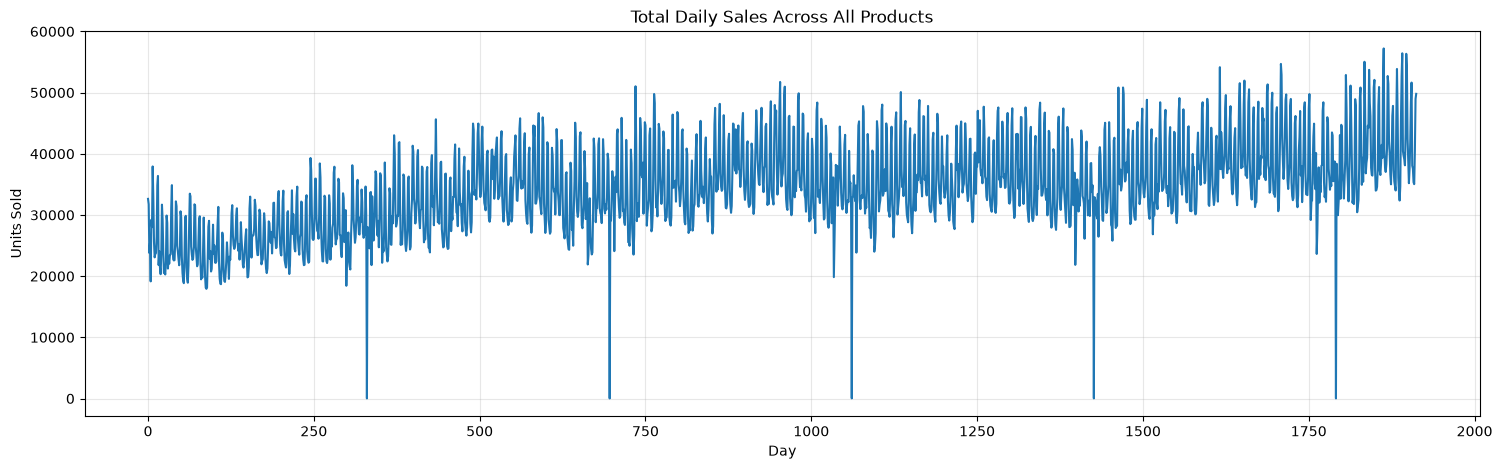

In [20]:
daily_sales = sales.iloc[:, 6:].sum(axis=0)

plt.figure(figsize=(18,5))
plt.plot(daily_sales.values)
plt.title("Total Daily Sales Across All Products")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.grid(alpha=0.3)
plt.show

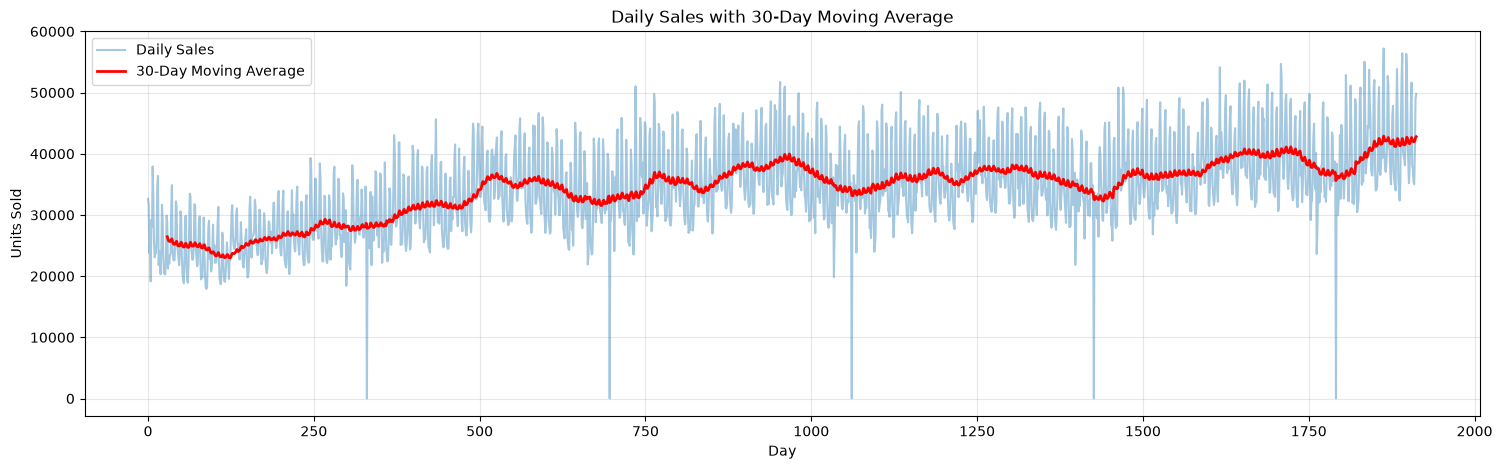

In [21]:
rolling_30 = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(18,5))
plt.plot(daily_sales.values, alpha=0.4, label="Daily Sales")
plt.plot(rolling_30.values, color="red", linewidth=2,
         label="30-Day Moving Average")

plt.title("Daily Sales with 30-Day Moving Average")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)

top_products = (
    sales[["id", "cat_id", "dept_id", "total_sales"]]
    .sort_values("total_sales", ascending=False)
)

top_products.head(10)

,id,cat_id,dept_id,total_sales
8412,FOODS_3_090_CA_3_validation,FOODS,FOODS_3,250502
18055,FOODS_3_586_TX_2_validation,FOODS,FOODS_3,192835
21104,FOODS_3_586_TX_3_validation,FOODS,FOODS_3,150122
8908,FOODS_3_586_CA_3_validation,FOODS,FOODS_3,134386
2314,FOODS_3_090_CA_1_validation,FOODS,FOODS_3,127203
29755,FOODS_3_090_WI_3_validation,FOODS,FOODS_3,121434
17559,FOODS_3_090_TX_2_validation,FOODS,FOODS_3,119496
20608,FOODS_3_090_TX_3_validation,FOODS,FOODS_3,114854
17721,FOODS_3_252_TX_2_validation,FOODS,FOODS_3,114153
15006,FOODS_3_586_TX_1_validation,FOODS,FOODS_3,112454


<Figure size 1000x600 with 0 Axes>

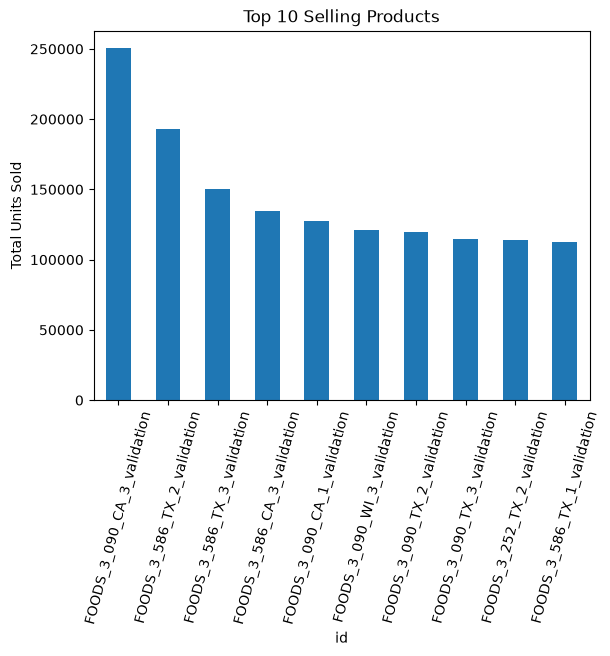

In [23]:
plt.figure(figsize=(10,6))

top_products.head(10).plot(
    x="id",
    y="total_sales",
    kind="bar",
    legend=False
)

plt.title("Top 10 Selling Products")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=75)
plt.show()

In [24]:
%whos

Variable            Type            Data/Info
---------------------------------------------
bar                 Rectangle       Rectangle(xy=(1.6, 0), wi<...>0.8, height=565, angle=0)
bars                BarContainer    <BarContainer object of 3 artists>
calendar            DataFrame       Shape: (1969, 14)
category_counts     Series          Shape: (3,)
category_products   Series          Shape: (3,)
daily_sales         Series          Shape: (1913,)
datasets            dict            n=4
day_columns         list            n=1913
df                  DataFrame       Shape: (60980, 29)
height              int64           565
name                str             Submission
np                  module          <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd                  module          <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt                 module          <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
prices              DataFrame       Shape: 

In [25]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)


In [26]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)

top_products = (
    sales[["id", "cat_id", "dept_id", "total_sales"]]
    .sort_values("total_sales", ascending=False)
)

top_products.head(10)

,id,cat_id,dept_id,total_sales
8412,FOODS_3_090_CA_3_validation,FOODS,FOODS_3,751506
18055,FOODS_3_586_TX_2_validation,FOODS,FOODS_3,578505
21104,FOODS_3_586_TX_3_validation,FOODS,FOODS_3,450366
8908,FOODS_3_586_CA_3_validation,FOODS,FOODS_3,403158
2314,FOODS_3_090_CA_1_validation,FOODS,FOODS_3,381609
29755,FOODS_3_090_WI_3_validation,FOODS,FOODS_3,364302
17559,FOODS_3_090_TX_2_validation,FOODS,FOODS_3,358488
20608,FOODS_3_090_TX_3_validation,FOODS,FOODS_3,344562
17721,FOODS_3_252_TX_2_validation,FOODS,FOODS_3,342459
15006,FOODS_3_586_TX_1_validation,FOODS,FOODS_3,337362


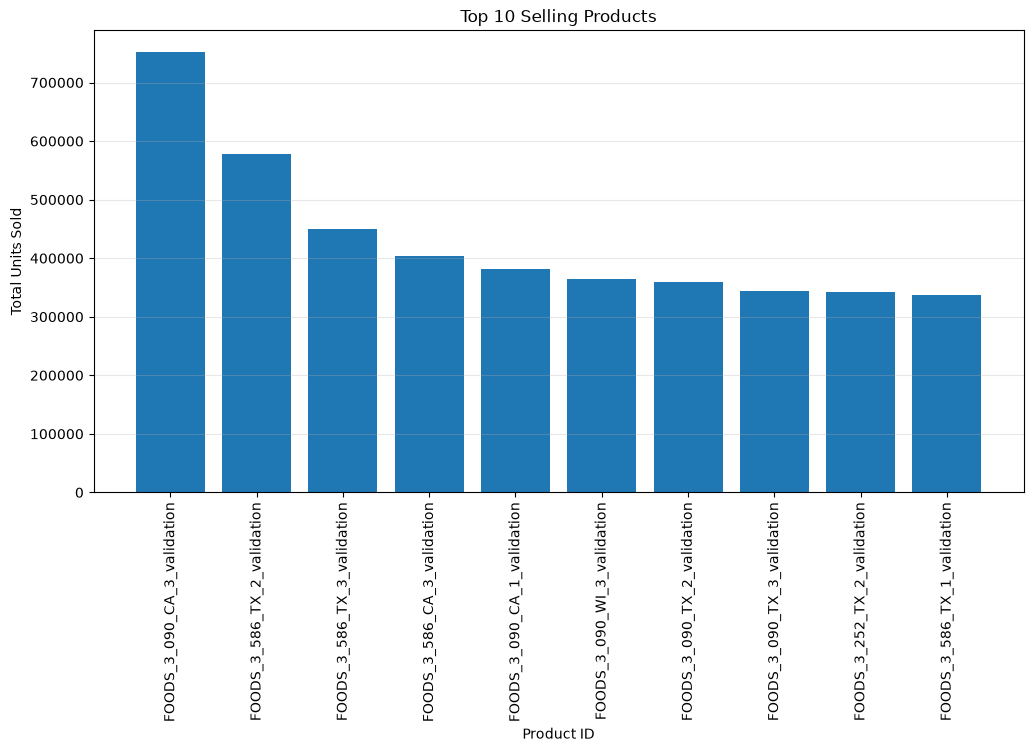

In [27]:
import matplotlib.pyplot as plt

top10 = top_products.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["id"], top10["total_sales"])
plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [28]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)

In [29]:
top20 = (
    sales[["id","cat_id","dept_id","store_id","total_sales"]]
    .sort_values("total_sales", ascending=False)
)

top20.head(20)

,id,cat_id,dept_id,store_id,total_sales
8412,FOODS_3_090_CA_3_validation,FOODS,FOODS_3,CA_3,1002008
18055,FOODS_3_586_TX_2_validation,FOODS,FOODS_3,TX_2,771340
21104,FOODS_3_586_TX_3_validation,FOODS,FOODS_3,TX_3,600488
8908,FOODS_3_586_CA_3_validation,FOODS,FOODS_3,CA_3,537544
2314,FOODS_3_090_CA_1_validation,FOODS,FOODS_3,CA_1,508812
29755,FOODS_3_090_WI_3_validation,FOODS,FOODS_3,WI_3,485736
17559,FOODS_3_090_TX_2_validation,FOODS,FOODS_3,TX_2,477984
20608,FOODS_3_090_TX_3_validation,FOODS,FOODS_3,TX_3,459416
17721,FOODS_3_252_TX_2_validation,FOODS,FOODS_3,TX_2,456612
15006,FOODS_3_586_TX_1_validation,FOODS,FOODS_3,TX_1,449816


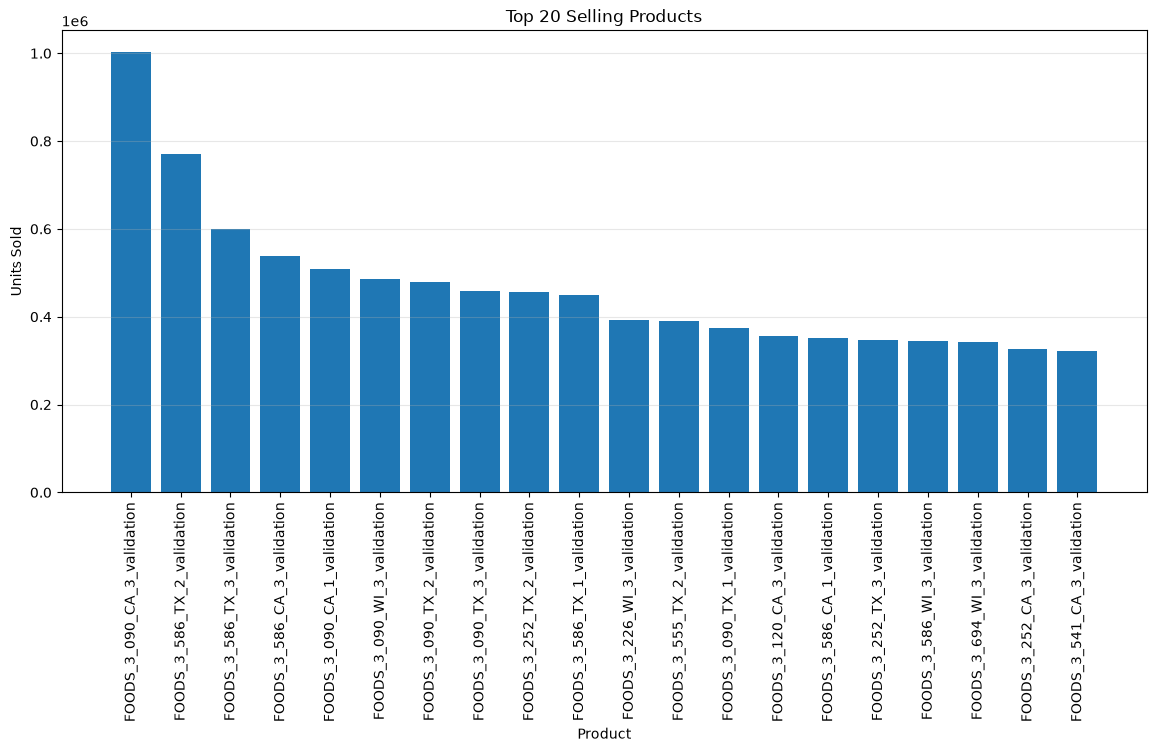

In [30]:
plt.figure(figsize=(14,6))

plt.bar(top20.head(20)["id"],
        top20.head(20)["total_sales"])

plt.xticks(rotation=90)
plt.ylabel("Units Sold")
plt.xlabel("Product")
plt.title("Top 20 Selling Products")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [31]:
bottom20 = (
    sales[["id","cat_id","dept_id","store_id","total_sales"]]
    .sort_values("total_sales")
)

bottom20.head(20)

,id,cat_id,dept_id,store_id,total_sales
6682,HOUSEHOLD_1_020_CA_3_validation,HOUSEHOLD,HOUSEHOLD_1,CA_3,40
6048,FOODS_3_778_CA_2_validation,FOODS,FOODS_3,CA_2,48
27606,HOBBIES_1_170_WI_3_validation,HOBBIES,HOBBIES_1,WI_3,52
20192,FOODS_2_071_TX_3_validation,FOODS,FOODS_2,TX_3,64
26276,FOODS_2_057_WI_2_validation,FOODS,FOODS_2,WI_2,64
6992,HOUSEHOLD_1_336_CA_3_validation,HOUSEHOLD,HOUSEHOLD_1,CA_3,72
6733,HOUSEHOLD_1_073_CA_3_validation,HOUSEHOLD,HOUSEHOLD_1,CA_3,76
10458,HOUSEHOLD_2_216_CA_4_validation,HOUSEHOLD,HOUSEHOLD_2,CA_4,76
10214,HOUSEHOLD_1_512_CA_4_validation,HOUSEHOLD,HOUSEHOLD_1,CA_4,80
10549,HOUSEHOLD_2_307_CA_4_validation,HOUSEHOLD,HOUSEHOLD_2,CA_4,84


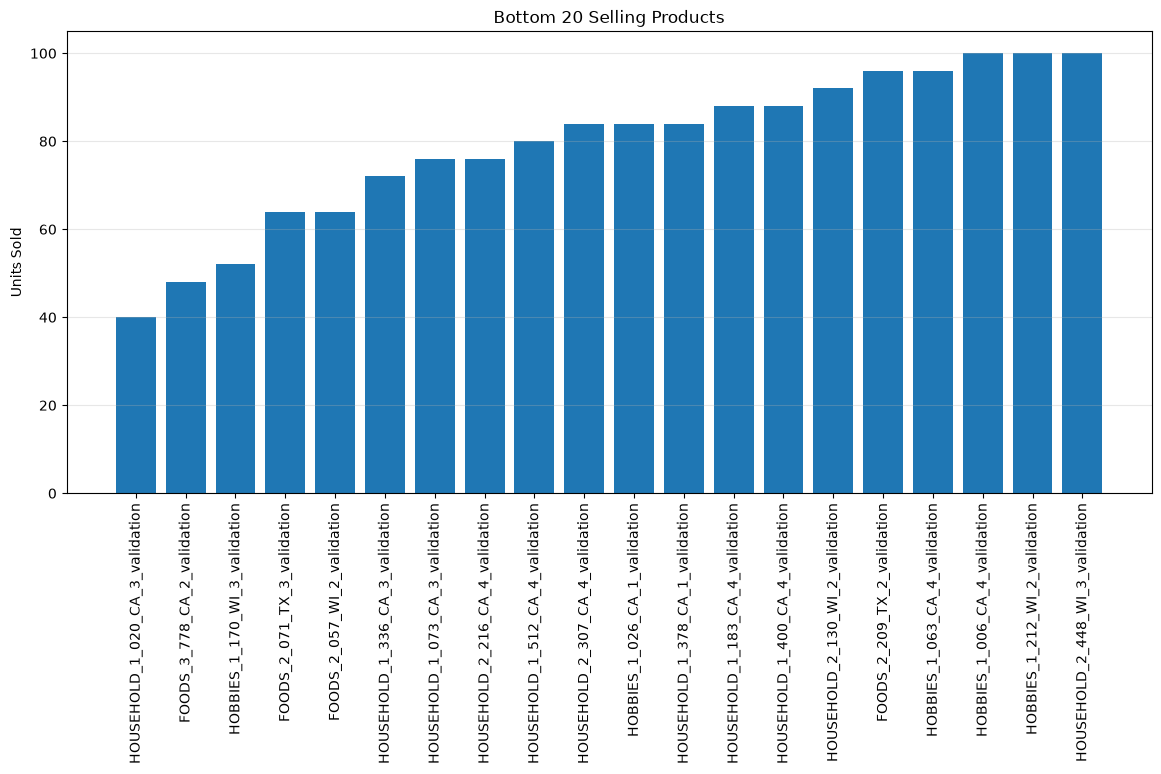

In [32]:
plt.figure(figsize=(14,6))

plt.bar(bottom20.head(20)["id"],
        bottom20.head(20)["total_sales"])

plt.xticks(rotation=90)

plt.title("Bottom 20 Selling Products")
plt.ylabel("Units Sold")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [33]:
category_sales = (
    sales.groupby("cat_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

category_sales

cat_id
FOODS        180359756
HOUSEHOLD     57922680
HOBBIES       24499200
Name: total_sales, dtype: int64

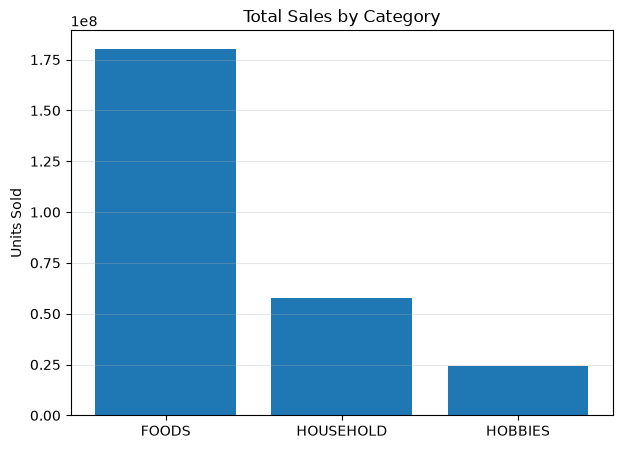

In [34]:
plt.figure(figsize=(7,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.title("Total Sales by Category")
plt.ylabel("Units Sold")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [35]:
dept_sales = (
    sales.groupby("dept_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

dept_sales.head(10)

dept_id
FOODS_3        129488304
HOUSEHOLD_1     46002104
FOODS_2         30519288
HOBBIES_1       22385840
FOODS_1         20352164
HOUSEHOLD_2     11920576
HOBBIES_2        2113360
Name: total_sales, dtype: int64

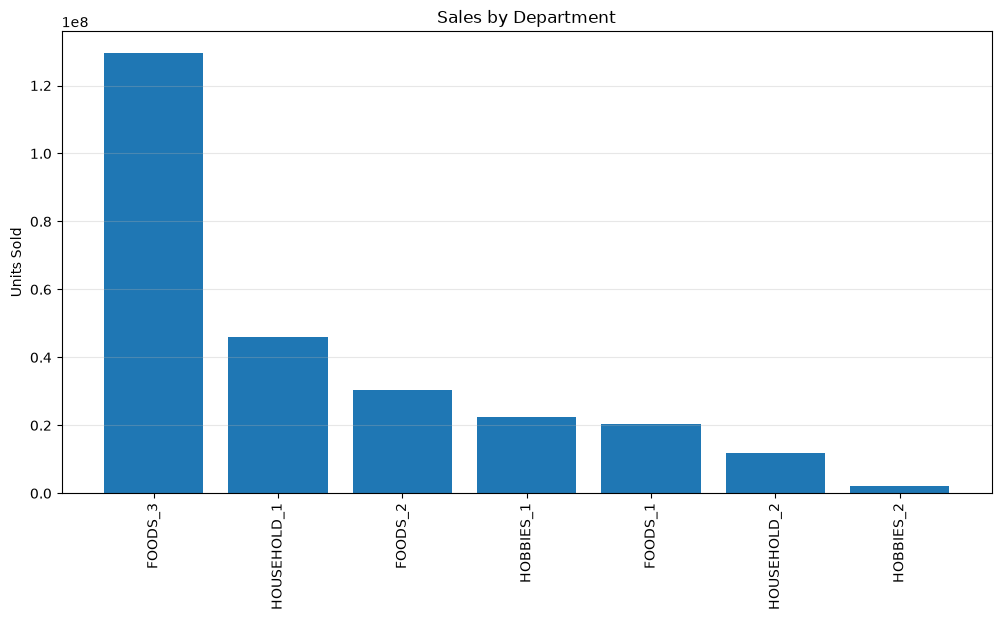

In [36]:
plt.figure(figsize=(12,6))

plt.bar(dept_sales.index,
        dept_sales.values)

plt.xticks(rotation=90)

plt.title("Sales by Department")
plt.ylabel("Units Sold")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [37]:
state_sales = (
    sales.groupby("state_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

state_sales

state_id
CA    114702188
TX     75596024
WI     72483424
Name: total_sales, dtype: int64

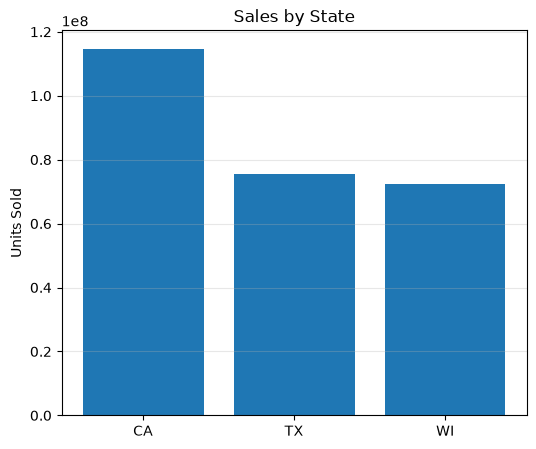

In [38]:
plt.figure(figsize=(6,5))

plt.bar(state_sales.index,
        state_sales.values)

plt.title("Sales by State")
plt.ylabel("Units Sold")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [39]:
store_sales = (
    sales.groupby("store_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

store_sales

store_id
CA_3    44752720
CA_1    30792864
TX_2    28857536
WI_2    26176048
WI_3    25711128
TX_3    24357320
CA_2    22741900
TX_1    22381168
WI_1    20596248
CA_4    16414704
Name: total_sales, dtype: int64

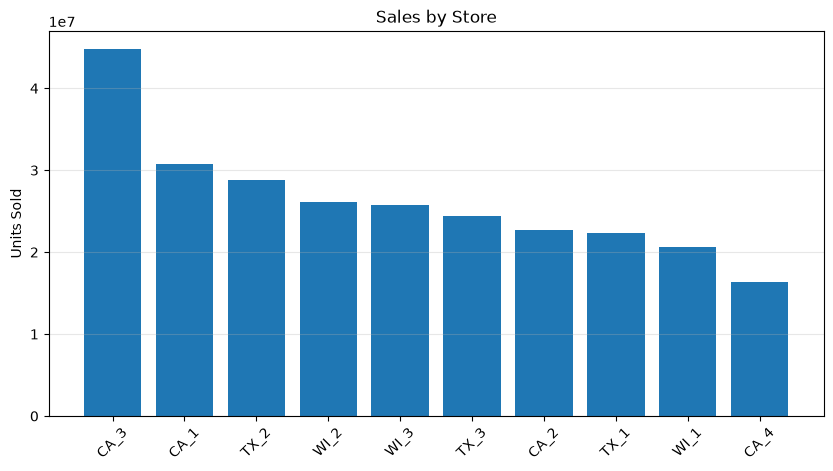

In [40]:
plt.figure(figsize=(10,5))

plt.bar(store_sales.index,
        store_sales.values)

plt.xticks(rotation=45)

plt.title("Sales by Store")
plt.ylabel("Units Sold")

plt.grid(axis='y', alpha=0.3)

plt.show()

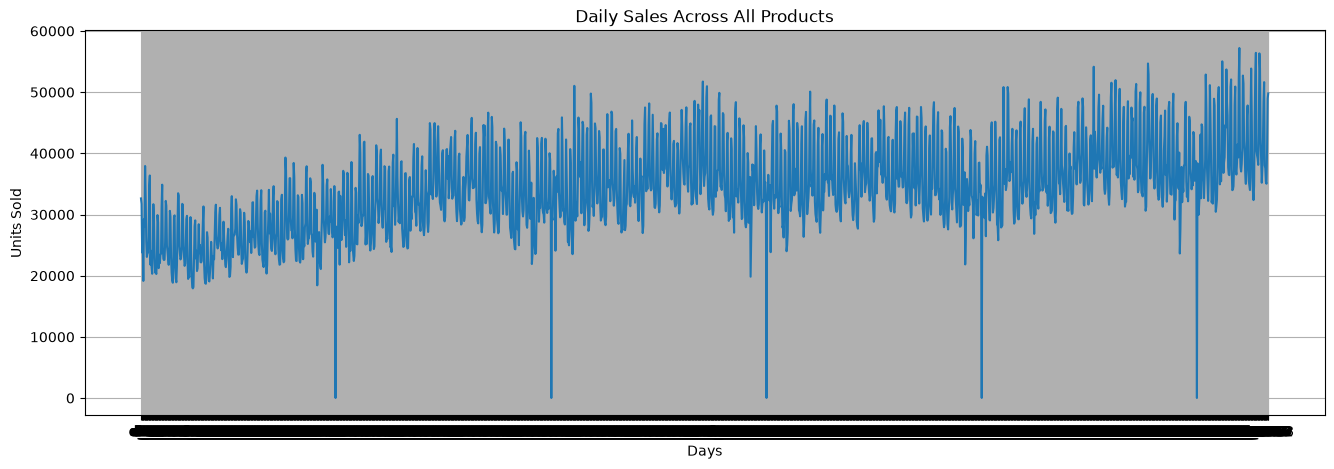

In [41]:
daily_sales = sales[day_columns].sum()

plt.figure(figsize=(16,5))
plt.plot(daily_sales)
plt.title("Daily Sales Across All Products")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()

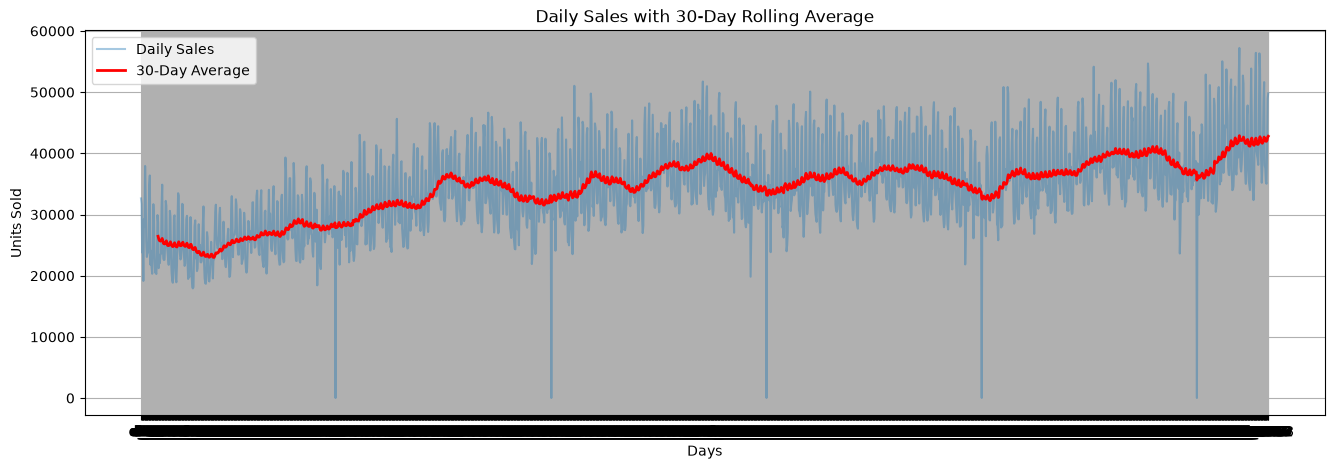

In [42]:
rolling_30 = daily_sales.rolling(30).mean()

plt.figure(figsize=(16,5))
plt.plot(daily_sales, alpha=0.4, label='Daily Sales')
plt.plot(rolling_30, color='red', linewidth=2, label='30-Day Average')

plt.title("Daily Sales with 30-Day Rolling Average")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()

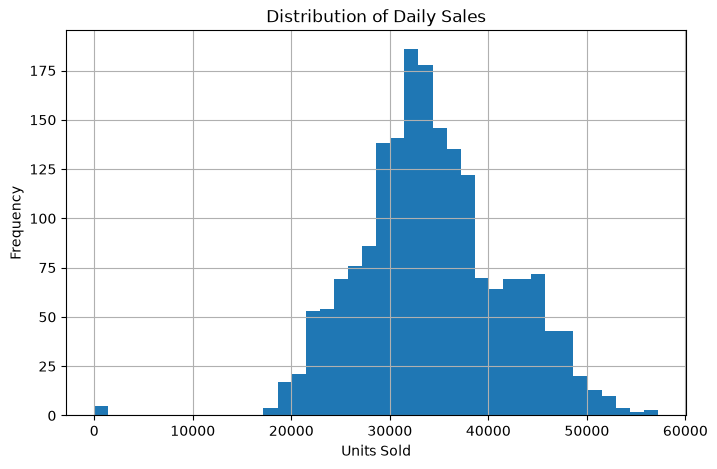

In [43]:
plt.figure(figsize=(8,5))
plt.hist(daily_sales, bins=40)

plt.title("Distribution of Daily Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

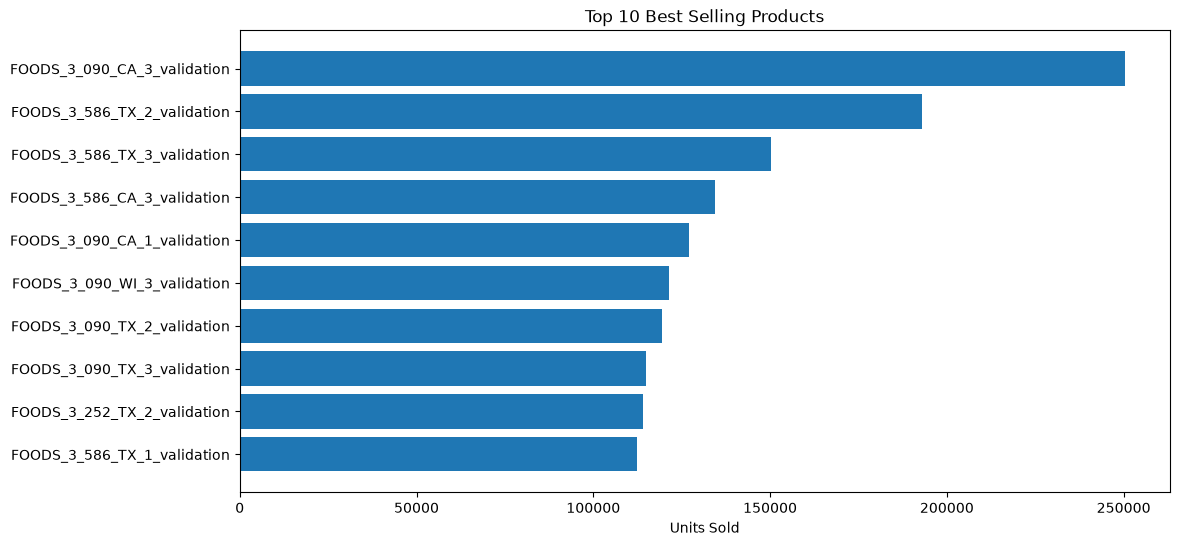

In [44]:
product_sales = sales[day_columns].sum(axis=1)

top10 = sales.loc[
    product_sales.nlargest(10).index,
    ['id']
].copy()

top10['Total Sales'] = product_sales.nlargest(10).values

plt.figure(figsize=(12,6))
plt.barh(top10['id'], top10['Total Sales'])

plt.title("Top 10 Best Selling Products")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()

plt.show()

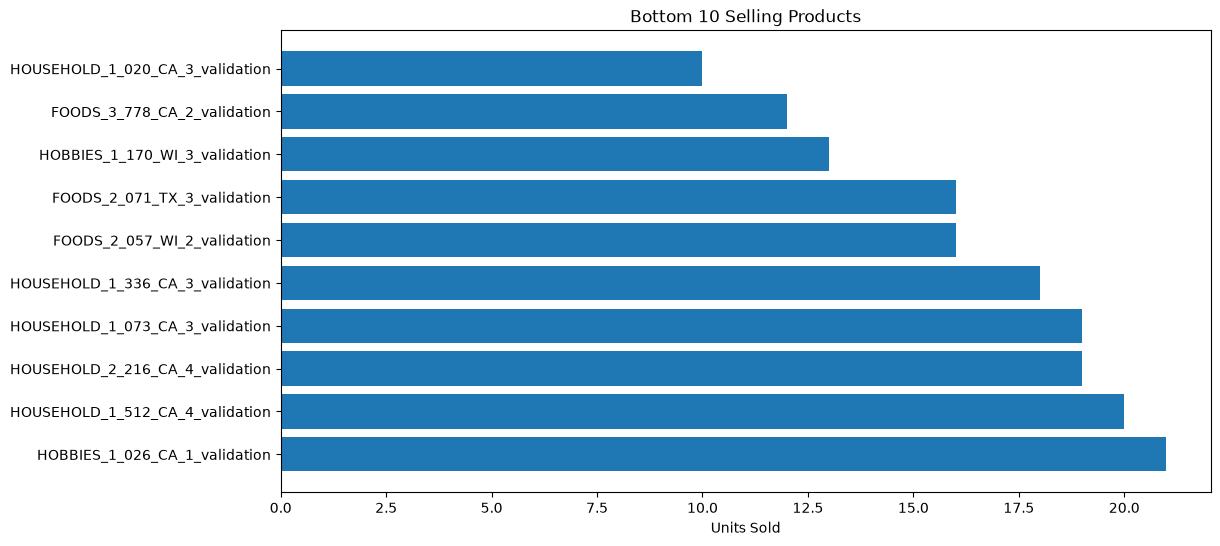

In [45]:
bottom10 = sales.loc[
    product_sales.nsmallest(10).index,
    ['id']
].copy()

bottom10['Total Sales'] = product_sales.nsmallest(10).values

plt.figure(figsize=(12,6))
plt.barh(bottom10['id'], bottom10['Total Sales'])

plt.title("Bottom 10 Selling Products")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()

plt.show()

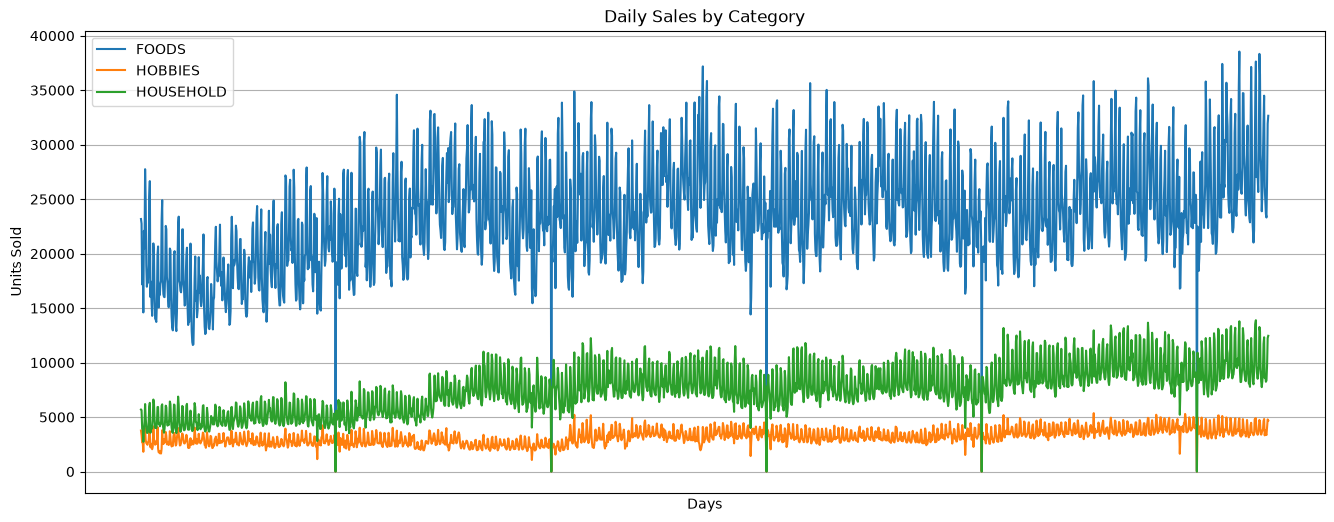

In [46]:
category_daily = sales.groupby('cat_id')[day_columns].sum().T

plt.figure(figsize=(16,6))

for category in category_daily.columns:
    plt.plot(category_daily.index,
             category_daily[category],
             label=category)

plt.title("Daily Sales by Category")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks([])   # Hide crowded day labels
plt.grid(True)

plt.show()

In [47]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [48]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [49]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [50]:
daily_sales = sales[day_columns].sum()

calendar_sales = calendar[['d','weekday']].copy()



In [51]:
daily_sales_df = pd.DataFrame({
    'd': day_columns,
    'Sales': daily_sales.values
})

calendar_sales = calendar.merge(daily_sales_df, on='d')

In [52]:
daily_sales = sales[day_columns].sum()

calendar_sales = calendar[['d','weekday']].copy()



In [53]:
calendar_sales = calendar[calendar['d'].isin(day_columns)].copy()

calendar_sales['Sales'] = daily_sales.values

In [54]:
print(calendar_sales.shape)
print(len(daily_sales))

(1913, 15)
1913


In [55]:
calendar_sales.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,Sales
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,32631
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,31749
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,23783
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,25412
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,19146


In [56]:
daily_sales_df = pd.DataFrame({
    'd': day_columns,
    'Sales': daily_sales.values
})

calendar_sales = calendar.merge(daily_sales_df, on='d')

In [57]:
calendar_sales.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,Sales
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,32631
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,31749
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,23783
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,25412
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,19146


In [58]:
# Total sales for each day
daily_sales = sales[day_columns].sum()

# Create a copy of calendar
calendar_sales = calendar.copy()

# Keep only the first 1913 days
calendar_sales = calendar_sales.iloc[:len(daily_sales)].copy()

# Add total sales
calendar_sales["Sales"] = daily_sales.values

# Check
print(calendar_sales.shape)
print(calendar_sales.columns)
calendar_sales.head()

(1913, 15)
Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'Sales'],
      dtype='str')


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,Sales
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,32631
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,31749
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,23783
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,25412
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,19146


In [59]:
print(calendar_sales.shape)
print(calendar_sales[['date', 'd', 'Sales']].head())
print(calendar_sales[['date', 'd', 'Sales']].tail())

(1913, 15)
         date    d  Sales
0  2011-01-29  d_1  32631
1  2011-01-30  d_2  31749
2  2011-01-31  d_3  23783
3  2011-02-01  d_4  25412
4  2011-02-02  d_5  19146
            date       d  Sales
1908  2016-04-20  d_1909  35343
1909  2016-04-21  d_1910  35033
1910  2016-04-22  d_1911  40517
1911  2016-04-23  d_1912  48962
1912  2016-04-24  d_1913  49795


In [60]:
weekday_sales = calendar_sales.groupby("weekday")["Sales"].mean()

weekday_sales = weekday_sales.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(weekday_sales)

weekday
Monday       32852.967033
Tuesday      30368.780220
Wednesday    30010.021978
Thursday     30205.007326
Friday       34225.985348
Saturday     41546.894161
Sunday       41130.021898
Name: Sales, dtype: float64


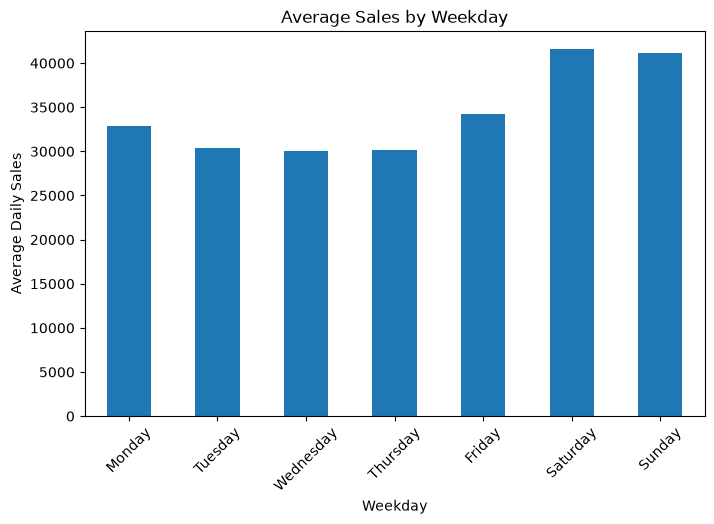

In [61]:
plt.figure(figsize=(8,5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)

plt.show()

The data shows a clear weekly seasonality. Sales peak on weekends, especially Saturdays, while mid-week sales are comparatively lower. This indicates that customer purchasing behavior is strongly influenced by the day of the week. Therefore, including the weekday as a feature in a forecasting model is likely to improve prediction accuracy.

In [62]:
monthly_sales = calendar_sales.groupby("month")["Sales"].mean()

print(monthly_sales)

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: Sales, dtype: float64


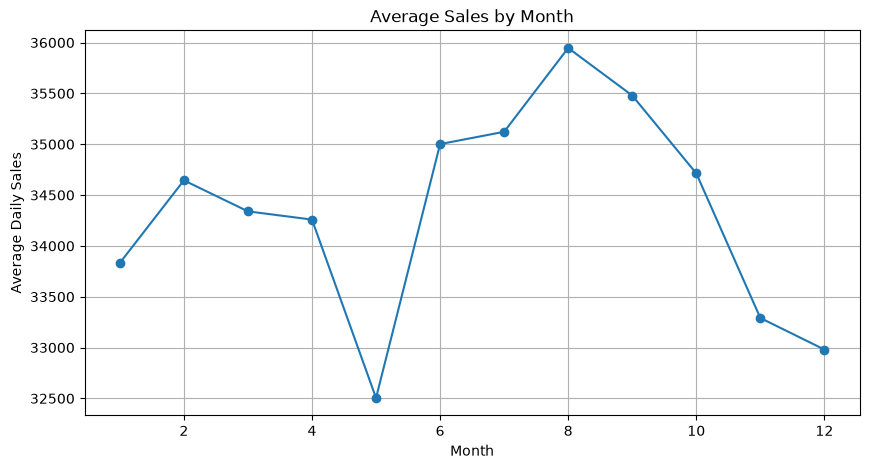

In [63]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.grid(True)

plt.show()

Monthly analysis indicates moderate seasonality. August records the highest average sales, while May shows the lowest. However, the monthly variation is relatively small compared to the strong weekly pattern observed earlier, suggesting that weekday is likely to be a more influential feature than month in the forecasting model.

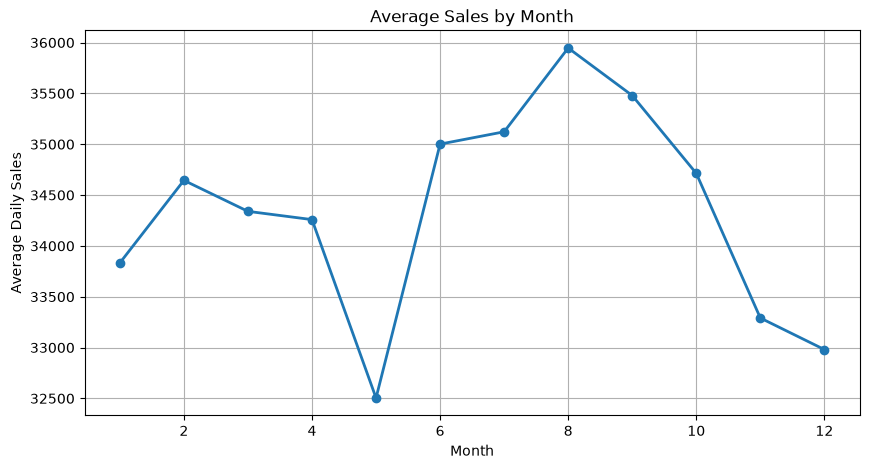

In [64]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o', linewidth=2)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.grid(True)

plt.show()

In [65]:
event_sales = (
    calendar_sales
    .groupby(calendar_sales['event_name_1'].notna())['Sales']
    .mean()
)

event_sales.index = ['No Event', 'Event']

print(event_sales)

No Event    34489.207504
Event       32655.149351
Name: Sales, dtype: float64


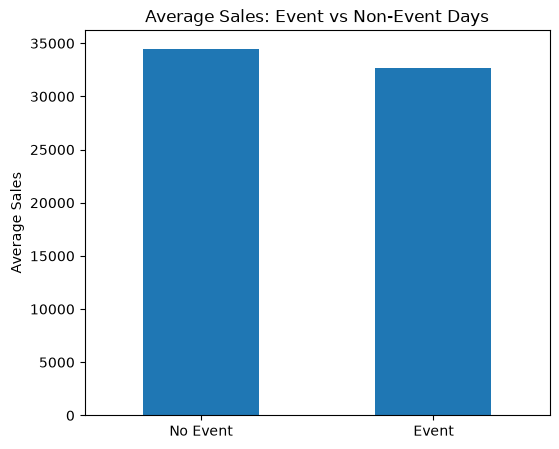

In [66]:
plt.figure(figsize=(6,5))

event_sales.plot(kind='bar')

plt.title("Average Sales: Event vs Non-Event Days")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)

plt.show()

In [67]:
event_avg = (
    calendar_sales
    .groupby('event_name_1')['Sales']
    .mean()
    .sort_values(ascending=False)
)

print(event_avg.head(10))

event_name_1
LaborDay          42154.6
SuperBowl         40924.0
Easter            39517.6
OrthodoxEaster    38277.0
Father's day      36562.0
Purim End         35957.0
Eid al-Fitr       35267.6
ColumbusDay       35164.8
VeteransDay       35118.8
Ramadan starts    34779.6
Name: Sales, dtype: float64


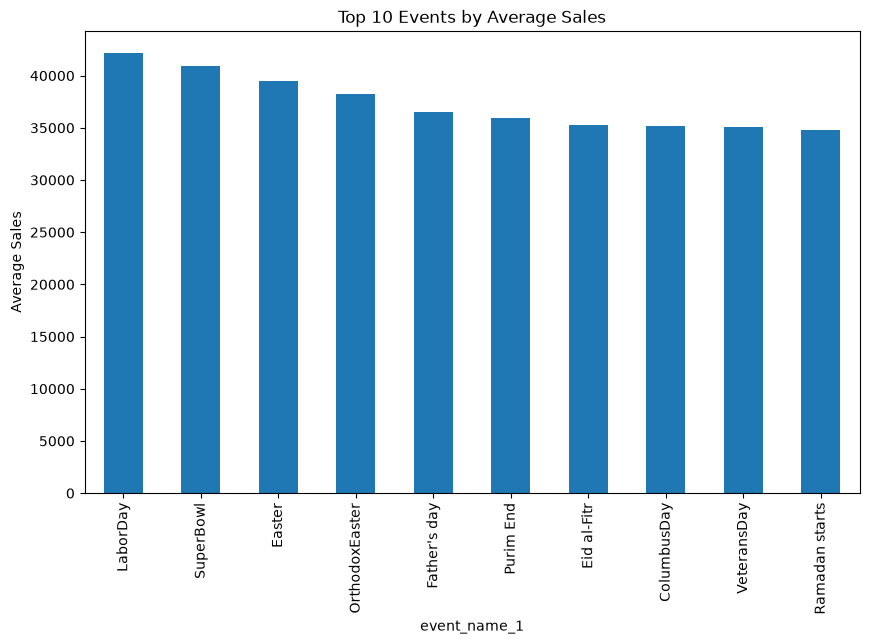

In [68]:
plt.figure(figsize=(10,6))

event_avg.head(10).plot(kind='bar')

plt.title("Top 10 Events by Average Sales")
plt.ylabel("Average Sales")

plt.show()

Are event days actually better than normal days?

In [69]:
event_vs_normal = (
    calendar_sales
    .groupby(calendar_sales['event_name_1'].notna())['Sales']
    .mean()
)

print(event_vs_normal)

event_name_1
False    34489.207504
True     32655.149351
Name: Sales, dtype: float64


In [70]:
event_vs_normal.index = ['No Event', 'Event']
print(event_vs_normal)

No Event    34489.207504
Event       32655.149351
Name: Sales, dtype: float64


In [71]:
day_columns = [col for col in sales.columns if col.startswith('d_')]

print(len(day_columns))

1913


In [72]:
sales_long = sales.melt(
    id_vars=[
        'id',
        'item_id',
        'dept_id',
        'cat_id',
        'store_id',
        'state_id'
    ],
    value_vars=day_columns,
    var_name='d',
    value_name='sales'
)

In [73]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [74]:
print(sales_long.shape)

(58327370, 8)


In [75]:
sales_long = sales_long.merge(
    calendar,
    on='d',
    how='left'
)

In [76]:
print(sales_long.shape)
sales_long.head()

(58327370, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [77]:
sales_long = sales_long.sort_values(
    ['id', 'date']
).reset_index(drop=True)

In [78]:
sample_items = sales.sample(1000, random_state=42)

sample_items = sample_items[[
    'item_id',
    'store_id'
] + day_columns]

In [79]:
sample_items.shape

(1000, 1915)

In [80]:
sample_long = sample_items.melt(
    id_vars=['item_id', 'store_id'],
    value_vars=day_columns,
    var_name='d',
    value_name='Sales'
)

In [81]:
sample_long.shape

(1913000, 4)

In [82]:
sample_long = sample_long.merge(
    calendar[['d', 'wm_yr_wk']],
    on='d',
    how='left'
)

In [83]:
sample_long.head()

,item_id,store_id,d,Sales,wm_yr_wk
0,FOODS_3_180,CA_1,d_1,0,11101
1,HOUSEHOLD_2_383,CA_3,d_1,2,11101
2,FOODS_3_409,CA_3,d_1,0,11101
3,FOODS_1_097,CA_2,d_1,0,11101
4,HOBBIES_1_272,TX_2,d_1,0,11101


In [84]:
sample_long = sample_long.merge(
    prices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

In [85]:
sample_long.head()

,item_id,store_id,d,Sales,wm_yr_wk,sell_price
0,FOODS_3_180,CA_1,d_1,0,11101,NaN
1,HOUSEHOLD_2_383,CA_3,d_1,2,11101,3.97
2,FOODS_3_409,CA_3,d_1,0,11101,NaN
3,FOODS_1_097,CA_2,d_1,0,11101,NaN
4,HOBBIES_1_272,TX_2,d_1,0,11101,NaN


In [86]:
sample_long['Revenue'] = (
    sample_long['Sales'] *
    sample_long['sell_price']
)

In [87]:
sample_long[['Sales', 'sell_price', 'Revenue']].describe()

,Sales,sell_price,Revenue
count,1.913000e+06,1.492188e+06,1.492188e+06
mean,9.925050e-01,4.443153e+00,3.632281e+00
std,3.175110e+00,3.616720e+00,8.063069e+00
min,0.000000e+00,5.000000e-02,0.000000e+00
25%,0.000000e+00,2.120000e+00,0.000000e+00
50%,0.000000e+00,3.370000e+00,0.000000e+00
75%,1.000000e+00,5.860000e+00,4.330000e+00
max,6.340000e+02,3.098000e+01,1.496240e+03


In [88]:
top_revenue = (
    sample_long
    .groupby('item_id')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_revenue)

item_id
HOUSEHOLD_1_535    88470.21
FOODS_3_318        69086.94
HOBBIES_1_225      63765.93
FOODS_3_723        60964.95
FOODS_2_368        60356.54
FOODS_3_252        56226.18
FOODS_3_652        55907.06
FOODS_3_327        54353.90
HOBBIES_1_345      52966.62
FOODS_1_183        36189.96
Name: Revenue, dtype: float64


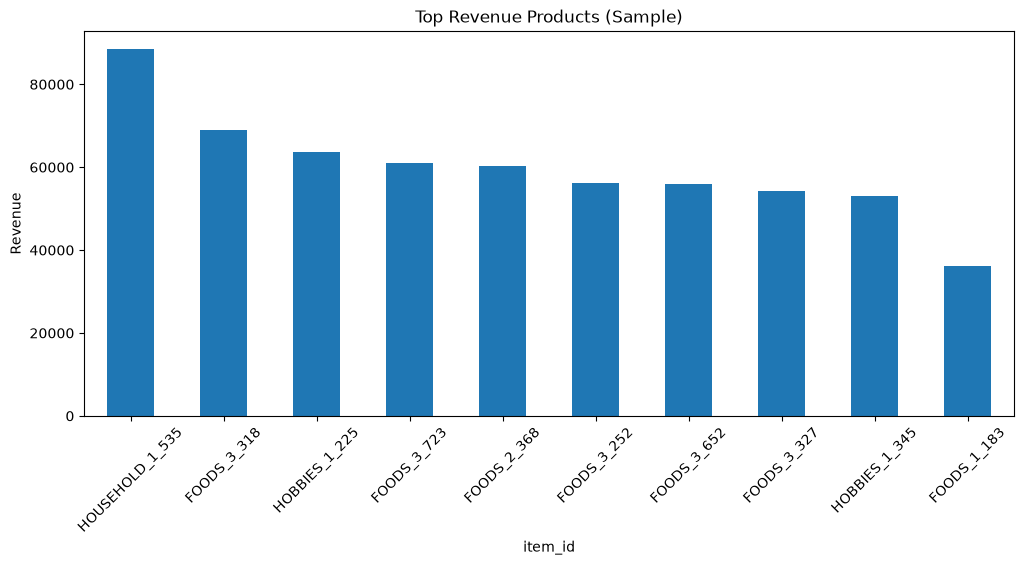

In [89]:
plt.figure(figsize=(12,5))

top_revenue.plot(kind='bar')

plt.title("Top Revenue Products (Sample)")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [90]:
sample_long.head()

,item_id,store_id,d,Sales,wm_yr_wk,sell_price,Revenue
0,FOODS_3_180,CA_1,d_1,0,11101,NaN,NaN
1,HOUSEHOLD_2_383,CA_3,d_1,2,11101,3.97,7.94
2,FOODS_3_409,CA_3,d_1,0,11101,NaN,NaN
3,FOODS_1_097,CA_2,d_1,0,11101,NaN,NaN
4,HOBBIES_1_272,TX_2,d_1,0,11101,NaN,NaN


In [91]:
sample_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 1913000 entries, 0 to 1912999
Data columns (total 7 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item_id     str    
 1   store_id    str    
 2   d           str    
 3   Sales       int64  
 4   wm_yr_wk    int64  
 5   sell_price  float64
 6   Revenue     float64
dtypes: float64(2), int64(2), str(3)
memory usage: 102.2 MB


In [92]:
sample_long["sell_price"].describe()

count    1.492188e+06
mean     4.443153e+00
std      3.616720e+00
min      5.000000e-02
25%      2.120000e+00
50%      3.370000e+00
75%      5.860000e+00
max      3.098000e+01
Name: sell_price, dtype: float64

In [93]:
sample_long["sell_price"].isna().sum()

np.int64(420812)

In [94]:
sample_long["sell_price"].isna().mean()*100

np.float64(21.997490852064818)

In [95]:
sample_long["Revenue"].describe()

count    1.492188e+06
mean     3.632281e+00
std      8.063069e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.330000e+00
max      1.496240e+03
Name: Revenue, dtype: float64

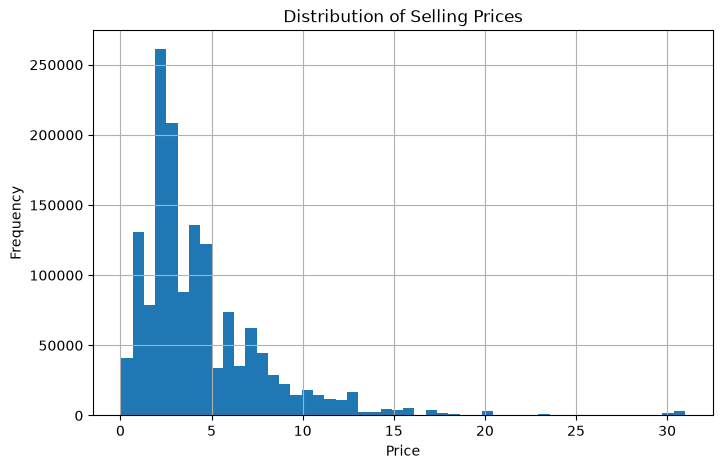

In [96]:
plt.figure(figsize=(8,5))

sample_long["sell_price"].dropna().hist(bins=50)

plt.title("Distribution of Selling Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [97]:
top_prices = (
    sample_long
    .groupby("item_id")["sell_price"]
    .max()
    .sort_values(ascending=False)
)

top_prices.head(10)

item_id
HOBBIES_1_225      30.98
HOBBIES_1_354      23.98
HOUSEHOLD_1_378    22.98
HOBBIES_1_241      21.78
HOUSEHOLD_1_523    20.53
HOUSEHOLD_2_211    20.00
HOBBIES_1_180      19.98
HOUSEHOLD_1_412    18.87
HOBBIES_1_135      18.46
HOUSEHOLD_1_009    17.97
Name: sell_price, dtype: float64

In [98]:
top_revenue = (
    sample_long
    .groupby("item_id")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_revenue.head(10)

item_id
HOUSEHOLD_1_535    88470.21
FOODS_3_318        69086.94
HOBBIES_1_225      63765.93
FOODS_3_723        60964.95
FOODS_2_368        60356.54
FOODS_3_252        56226.18
FOODS_3_652        55907.06
FOODS_3_327        54353.90
HOBBIES_1_345      52966.62
FOODS_1_183        36189.96
Name: Revenue, dtype: float64

In [99]:
store_sales = (
    sample_long
    .groupby("store_id")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(store_sales)

store_id
CA_3    371267
CA_2    212317
WI_3    209169
TX_1    193553
WI_2    169059
CA_1    167391
TX_2    153231
CA_4    149558
TX_3    142604
WI_1    130513
Name: Sales, dtype: int64


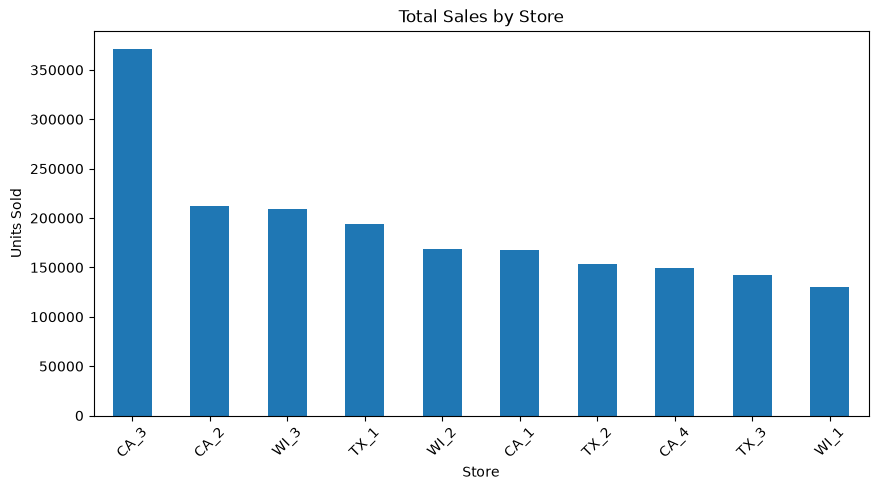

In [100]:
plt.figure(figsize=(10,5))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.show()

Store-level sales analysis shows noticeable variation in demand across stores. CA_3 records the highest unit sales, indicating strong customer demand, while WI_1 records the lowest. However, unit sales alone do not fully measure store performance; revenue analysis is required to determine overall business contribution.

In [101]:
store_revenue = (
    sample_long
    .groupby("store_id")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(store_revenue)

store_id
CA_3    946939.81
CA_1    654226.33
TX_1    549960.67
CA_2    531903.41
WI_3    509639.15
TX_2    501477.69
WI_2    489735.64
WI_1    438667.47
TX_3    408234.19
CA_4    389261.26
Name: Revenue, dtype: float64


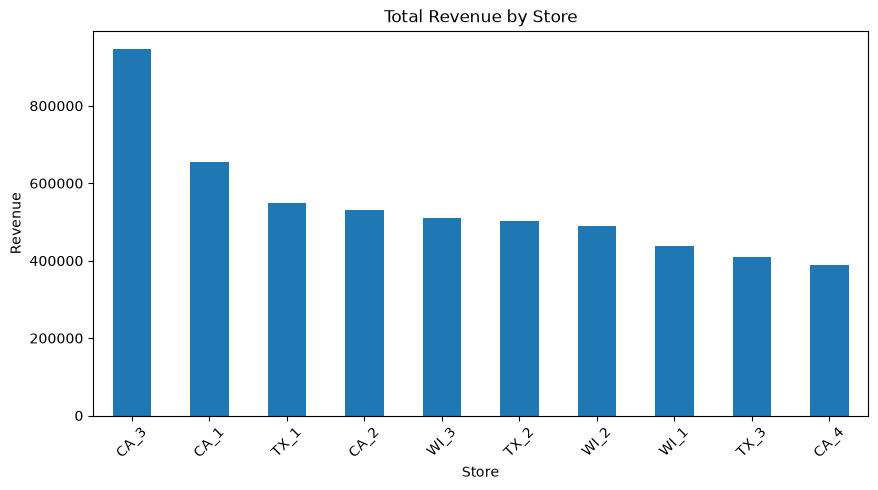

In [102]:
plt.figure(figsize=(10,5))

store_revenue.plot(kind="bar")

plt.title("Total Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

Revenue analysis shows that CA_3 is the highest revenue-generating store, consistent with its leading unit sales, indicating both strong demand and strong business contribution. In contrast, CA_4 generates the lowest revenue despite not having the lowest unit sales, suggesting differences in product pricing or sales mix across stores. This highlights the importance of analyzing both sales volume and revenue when evaluating store performance.

In [103]:
sample_long["State"] = sample_long["store_id"].str[:2]

sample_long[["store_id", "State"]].head()

,store_id,State
0,CA_1,CA
1,CA_3,CA
2,CA_3,CA
3,CA_2,CA
4,TX_2,TX


In [104]:
state_sales = (
    sample_long
    .groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales)

State
CA    900533
WI    508741
TX    489388
Name: Sales, dtype: int64


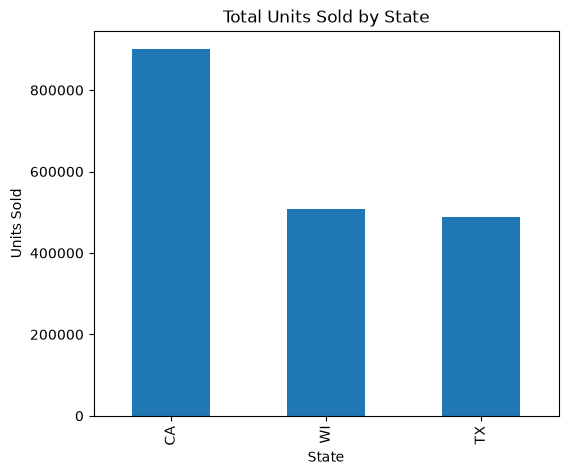

In [105]:
plt.figure(figsize=(6,5))

state_sales.plot(kind="bar")

plt.title("Total Units Sold by State")
plt.xlabel("State")
plt.ylabel("Units Sold")

plt.show()

In [106]:
state_revenue = (
    sample_long
    .groupby("State")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue)

State
CA    2522330.81
TX    1459672.55
WI    1438042.26
Name: Revenue, dtype: float64


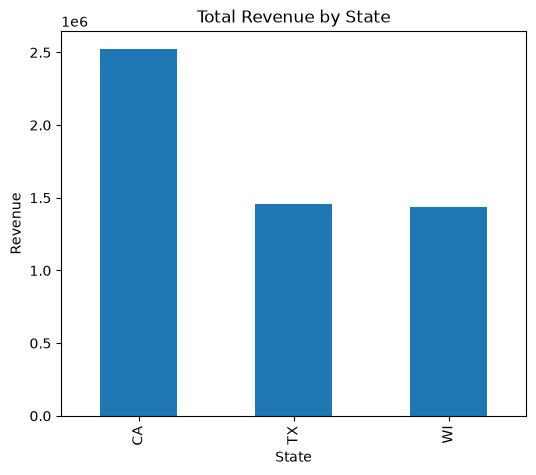

In [107]:
plt.figure(figsize=(6,5))

state_revenue.plot(kind="bar")

plt.title("Total Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

In [108]:
state_price = (
    sample_long
    .groupby("State")["sell_price"]
    .mean()
    .sort_values(ascending=False)
)

print(state_price)

State
WI    4.762594
TX    4.480472
CA    4.185885
Name: sell_price, dtype: float64


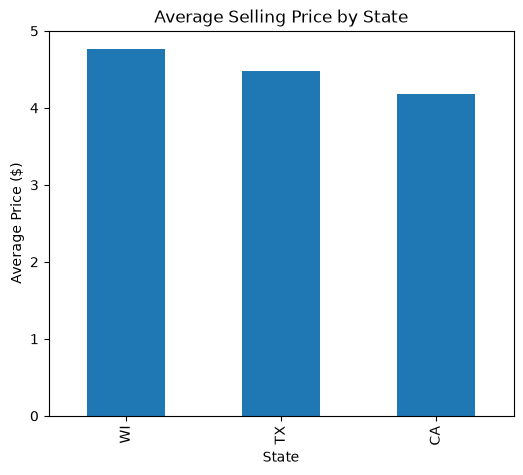

In [109]:
plt.figure(figsize=(6,5))

state_price.plot(kind="bar")

plt.title("Average Selling Price by State")
plt.xlabel("State")
plt.ylabel("Average Price ($)")

plt.show()

In [110]:
item_info = sales[['item_id', 'cat_id', 'dept_id']].drop_duplicates()

sample_long = sample_long.merge(
    item_info,
    on='item_id',
    how='left'
)

sample_long.head()

,item_id,store_id,d,Sales,wm_yr_wk,sell_price,Revenue,State,cat_id,dept_id
0,FOODS_3_180,CA_1,d_1,0,11101,NaN,NaN,CA,FOODS,FOODS_3
1,HOUSEHOLD_2_383,CA_3,d_1,2,11101,3.97,7.94,CA,HOUSEHOLD,HOUSEHOLD_2
2,FOODS_3_409,CA_3,d_1,0,11101,NaN,NaN,CA,FOODS,FOODS_3
3,FOODS_1_097,CA_2,d_1,0,11101,NaN,NaN,CA,FOODS,FOODS_1
4,HOBBIES_1_272,TX_2,d_1,0,11101,NaN,NaN,TX,HOBBIES,HOBBIES_1


In [111]:
top_products = (
    sample_long
    .groupby('item_id')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

item_id
FOODS_3_318        54770
FOODS_3_723        44780
FOODS_3_252        37221
HOUSEHOLD_1_521    30266
HOUSEHOLD_1_277    27759
HOBBIES_1_178      26971
HOBBIES_1_371      26172
FOODS_1_218        22230
FOODS_3_288        21951
FOODS_3_389        21341
Name: Sales, dtype: int64

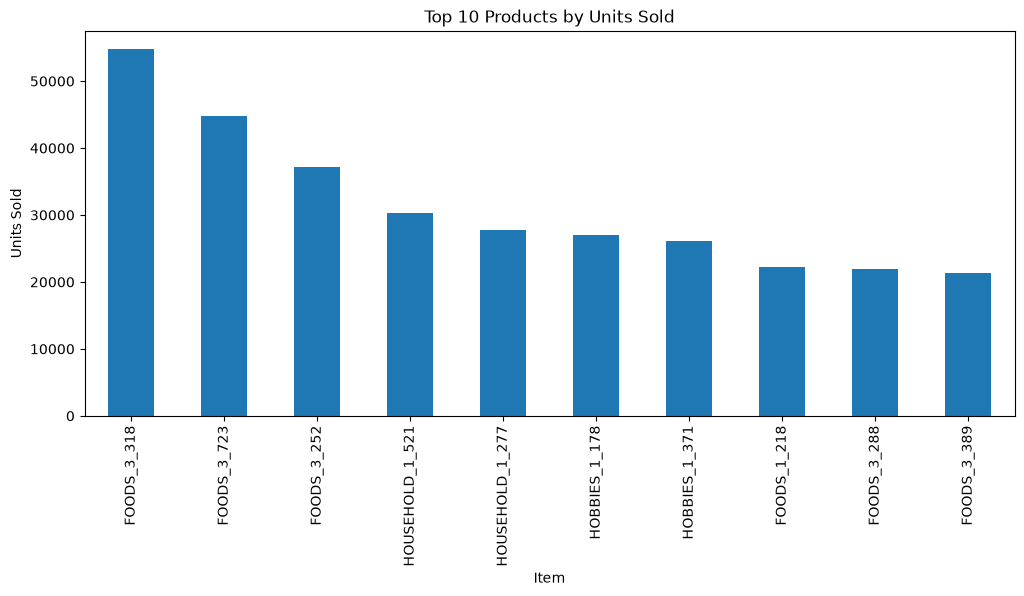

In [112]:
plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Item")
plt.ylabel("Units Sold")

plt.xticks(rotation=90)

plt.show()

In [113]:
top_revenue_products = (
    sample_long
    .groupby('item_id')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_products

item_id
HOUSEHOLD_1_535    88470.21
FOODS_3_318        69086.94
HOBBIES_1_225      63765.93
FOODS_3_723        60964.95
FOODS_2_368        60356.54
FOODS_3_252        56226.18
FOODS_3_652        55907.06
FOODS_3_327        54353.90
HOBBIES_1_345      52966.62
FOODS_1_183        36189.96
Name: Revenue, dtype: float64

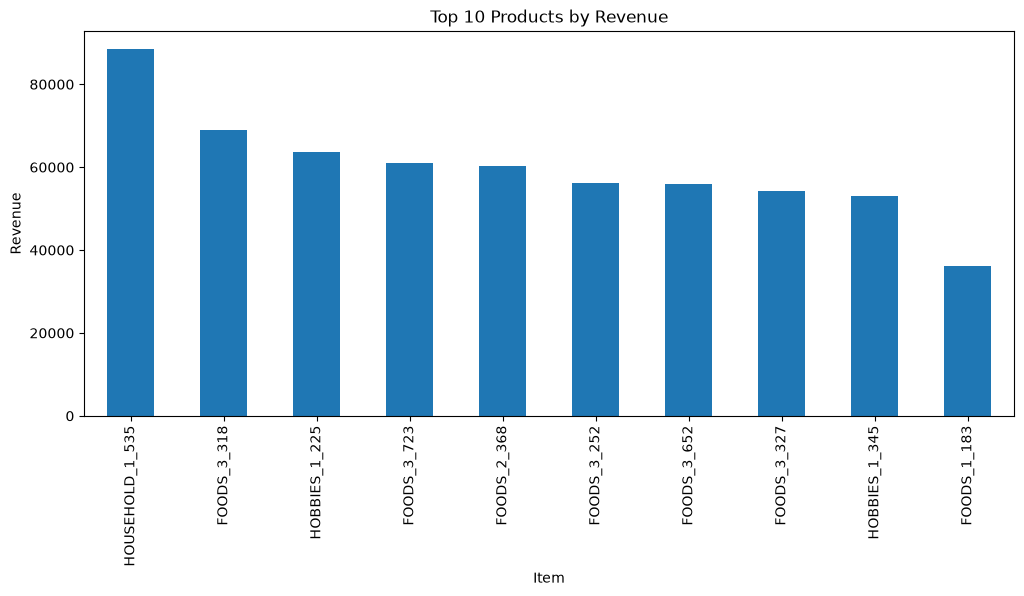

In [114]:
plt.figure(figsize=(12,5))

top_revenue_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Item")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [115]:
lowest_products = (
    sample_long
    .groupby('item_id')['Sales']
    .sum()
    .sort_values()
    .head(10)
)

lowest_products

item_id
HOBBIES_1_006      25
FOODS_2_096        40
HOBBIES_2_084      40
HOBBIES_2_119      44
HOBBIES_2_082      47
HOBBIES_2_110      49
HOUSEHOLD_2_077    50
HOUSEHOLD_2_396    50
HOUSEHOLD_2_151    55
HOBBIES_2_031      58
Name: Sales, dtype: int64

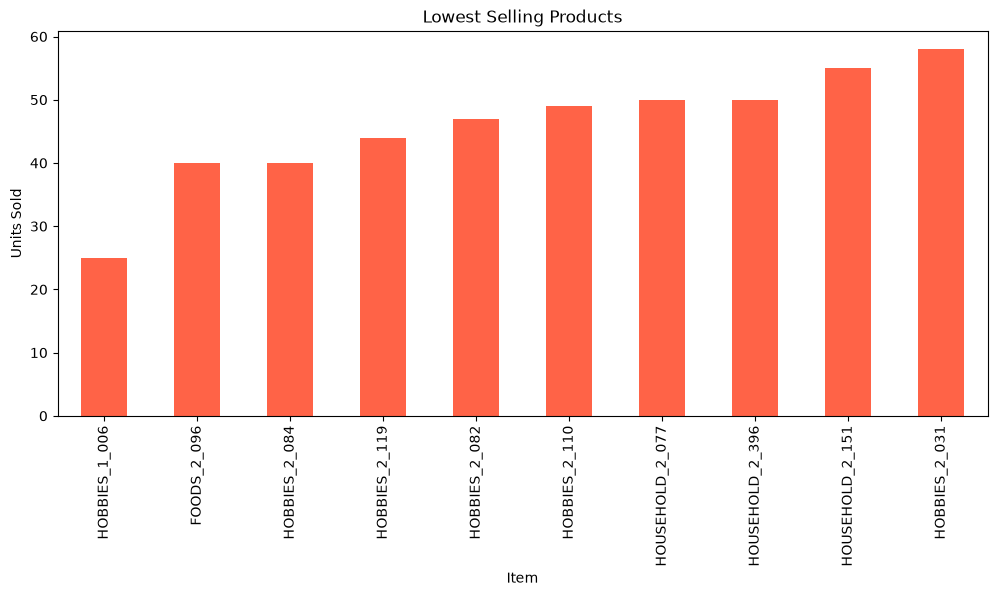

In [116]:
plt.figure(figsize=(12,5))

lowest_products.plot(kind='bar', color='tomato')

plt.title("Lowest Selling Products")
plt.xlabel("Item")
plt.ylabel("Units Sold")

plt.xticks(rotation=90)

plt.show()

In [117]:
top_product_categories = (
    sample_long[
        sample_long['item_id'].isin(top_products.index)
    ]
    .groupby('cat_id')['Sales']
    .sum()
)

top_product_categories

cat_id
FOODS        202293
HOBBIES       53143
HOUSEHOLD     58025
Name: Sales, dtype: int64

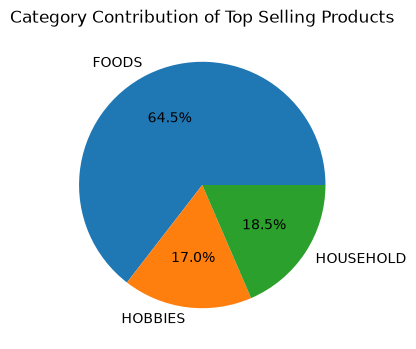

In [118]:
plt.figure(figsize=(6,4))

top_product_categories.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("Category Contribution of Top Selling Products")

plt.show()

In [119]:
store_category = sample_long.pivot_table(
    index='store_id',
    columns='cat_id',
    values='Sales',
    aggfunc='sum'
)

store_category

cat_id,FOODS,HOBBIES,HOUSEHOLD
store_id,,,
CA_1,103432,9477,54482
CA_2,114907,47409,50001
CA_3,230382,35428,105457
CA_4,87078,45854,16626
TX_1,139414,17053,37086
TX_2,86748,16526,49957
TX_3,96145,15418,31041
WI_1,79430,30427,20656
WI_2,107502,16049,45508


In [120]:
import seaborn as sns

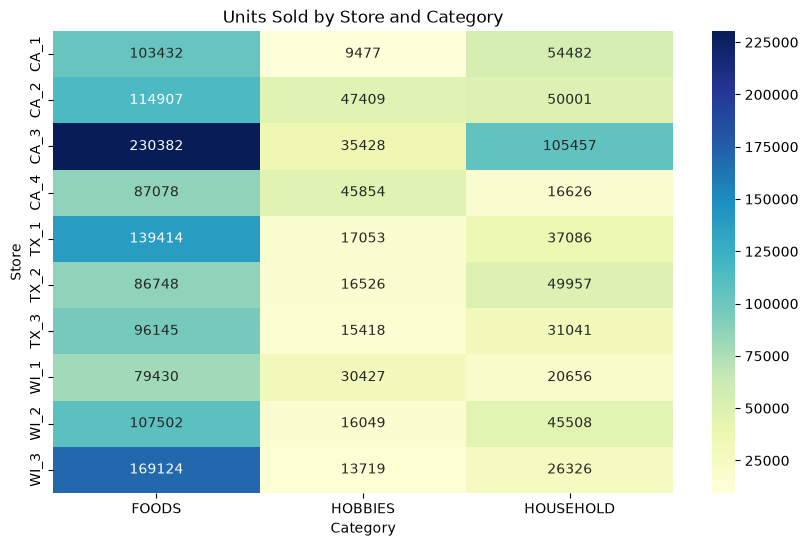

In [121]:
plt.figure(figsize=(10,6))

sns.heatmap(
    store_category,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Units Sold by Store and Category")

plt.xlabel("Category")
plt.ylabel("Store")

plt.show()

In [122]:
store_revenue = sample_long.pivot_table(
    index='store_id',
    columns='cat_id',
    values='Revenue',
    aggfunc='sum'
)

store_revenue

cat_id,FOODS,HOBBIES,HOUSEHOLD
store_id,,,
CA_1,306086.73,90661.17,257478.43
CA_2,258615.00,94081.82,179206.59
CA_3,511552.43,131051.22,304336.16
CA_4,244819.79,76592.52,67848.95
TX_1,341803.77,71348.38,136808.52
TX_2,257914.78,67134.36,176428.55
TX_3,204260.36,75636.78,128337.05
WI_1,185923.86,147487.31,105256.30
WI_2,248110.22,90492.91,151132.51


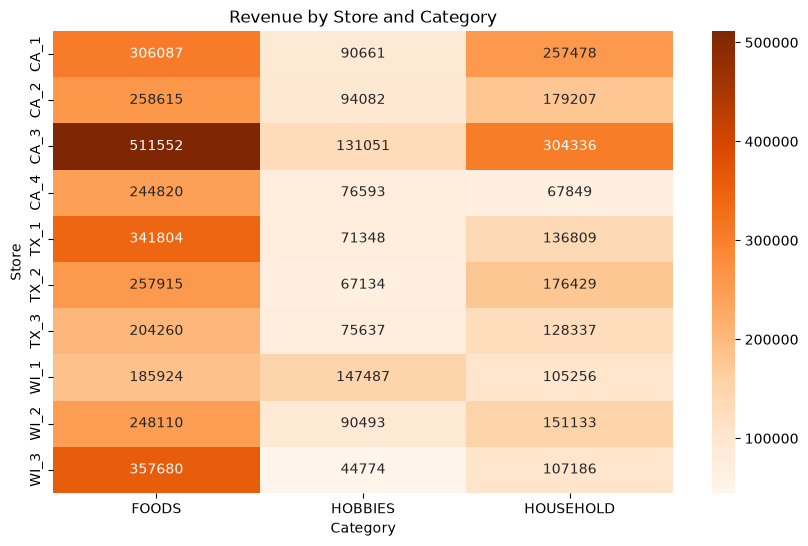

In [123]:
plt.figure(figsize=(10,6))

sns.heatmap(
    store_revenue,
    annot=True,
    fmt='.0f',
    cmap='Oranges'
)

plt.title("Revenue by Store and Category")

plt.xlabel("Category")
plt.ylabel("Store")

plt.show()

In [124]:
store_price = sample_long.pivot_table(
    index='store_id',
    columns='cat_id',
    values='sell_price',
    aggfunc='mean'
)

store_price

cat_id,FOODS,HOBBIES,HOUSEHOLD
store_id,,,
CA_1,3.282243,6.881732,5.285812
CA_2,3.264168,4.584466,4.665584
CA_3,2.622907,6.442451,5.279671
CA_4,3.455451,4.263076,5.165916
TX_1,3.280805,6.268824,5.567751
TX_2,3.461583,5.780449,4.795327
TX_3,2.741948,7.035165,5.353000
WI_1,3.520524,5.098363,5.463160
WI_2,2.804777,6.827402,5.767453


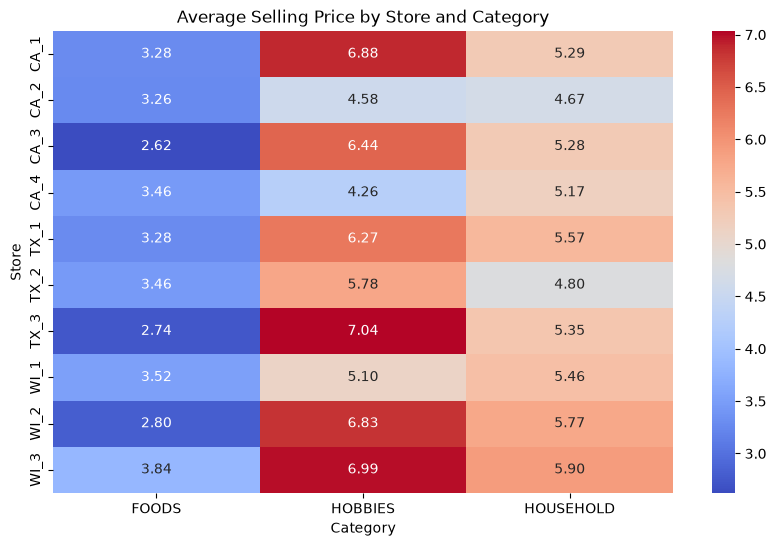

In [125]:
plt.figure(figsize=(10,6))

sns.heatmap(
    store_price,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Average Selling Price by Store and Category")

plt.xlabel("Category")
plt.ylabel("Store")

plt.show()

In [126]:
# Add date information
sample_long = sample_long.merge(
    calendar[
        [
            'd',
            'date',
            'weekday',
            'month',
            'year',
            'snap_CA',
            'snap_TX',
            'snap_WI',
            'event_name_1',
            'event_type_1'
        ]
    ],
    on='d',
    how='left'
)

In [127]:
sample_long.head()

,item_id,store_id,d,Sales,wm_yr_wk,sell_price,Revenue,State,cat_id,dept_id,date,weekday,month,year,snap_CA,snap_TX,snap_WI,event_name_1,event_type_1
0,FOODS_3_180,CA_1,d_1,0,11101,NaN,NaN,CA,FOODS,FOODS_3,2011-01-29,Saturday,1,2011,0,0,0,NaN,NaN
1,HOUSEHOLD_2_383,CA_3,d_1,2,11101,3.97,7.94,CA,HOUSEHOLD,HOUSEHOLD_2,2011-01-29,Saturday,1,2011,0,0,0,NaN,NaN
2,FOODS_3_409,CA_3,d_1,0,11101,NaN,NaN,CA,FOODS,FOODS_3,2011-01-29,Saturday,1,2011,0,0,0,NaN,NaN
3,FOODS_1_097,CA_2,d_1,0,11101,NaN,NaN,CA,FOODS,FOODS_1,2011-01-29,Saturday,1,2011,0,0,0,NaN,NaN
4,HOBBIES_1_272,TX_2,d_1,0,11101,NaN,NaN,TX,HOBBIES,HOBBIES_1,2011-01-29,Saturday,1,2011,0,0,0,NaN,NaN


In [129]:
sample_long.shape

(1913000, 19)

In [130]:
sample_long["is_weekend"] = sample_long["weekday"].isin(
    ["Saturday", "Sunday"]
).astype(int)

In [131]:
sample_long[["weekday", "is_weekend"]].drop_duplicates()

,weekday,is_weekend
0,Saturday,1
1000,Sunday,1
2000,Monday,0
3000,Tuesday,0
4000,Wednesday,0
5000,Thursday,0
6000,Friday,0


In [132]:
sample_long["quarter"] = (
    (sample_long["month"] - 1) // 3
) + 1

In [133]:
sample_long[["month", "quarter"]].drop_duplicates().sort_values("month")

,month,quarter
0,1,1
3000,2,1
31000,3,1
62000,4,2
92000,5,2
123000,6,2
153000,7,3
184000,8,3
215000,9,3
245000,10,4


In [134]:
sample_long["is_event"] = (
    sample_long["event_name_1"]
    .notna()
    .astype(int)
)

In [135]:
sample_long["is_event"].value_counts()

is_event
0    1759000
1     154000
Name: count, dtype: int64

In [136]:
day_map = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7
}

sample_long["weekday_num"] = sample_long["weekday"].map(day_map)

In [273]:
sample_long[
    ["weekday", "weekday_num"]
].drop_duplicates().sort_values("weekday_num")

,weekday,weekday_num
2000,Monday,1
3000,Tuesday,2
4000,Wednesday,3
5000,Thursday,4
6000,Friday,5
0,Saturday,6
1000,Sunday,7


In [137]:
sample_long = sample_long.sort_values(
    ["item_id", "store_id", "date"]
)

sample_long["lag_7"] = (
    sample_long
    .groupby(["item_id", "store_id"])["Sales"]
    .shift(7)
)

In [138]:
sample_long[
    [
        "item_id",
        "store_id",
        "date",
        "Sales",
        "lag_7"
    ]
].head(15)

,item_id,store_id,date,Sales,lag_7
475,FOODS_1_003,TX_3,2011-01-29,1,NaN
1475,FOODS_1_003,TX_3,2011-01-30,0,NaN
2475,FOODS_1_003,TX_3,2011-01-31,0,NaN
3475,FOODS_1_003,TX_3,2011-02-01,2,NaN
4475,FOODS_1_003,TX_3,2011-02-02,0,NaN
5475,FOODS_1_003,TX_3,2011-02-03,0,NaN
6475,FOODS_1_003,TX_3,2011-02-04,0,NaN
7475,FOODS_1_003,TX_3,2011-02-05,1,1.0
8475,FOODS_1_003,TX_3,2011-02-06,0,0.0
9475,FOODS_1_003,TX_3,2011-02-07,0,0.0


In [139]:
sample_long["lag_28"] = (
    sample_long
    .groupby(["item_id", "store_id"])["Sales"]
    .shift(28)
)

In [140]:
sample_long[
    ["item_id", "store_id", "date", "Sales", "lag_7", "lag_28"]
].head(35)

,item_id,store_id,date,Sales,lag_7,lag_28
475,FOODS_1_003,TX_3,2011-01-29,1,NaN,NaN
1475,FOODS_1_003,TX_3,2011-01-30,0,NaN,NaN
2475,FOODS_1_003,TX_3,2011-01-31,0,NaN,NaN
3475,FOODS_1_003,TX_3,2011-02-01,2,NaN,NaN
4475,FOODS_1_003,TX_3,2011-02-02,0,NaN,NaN
5475,FOODS_1_003,TX_3,2011-02-03,0,NaN,NaN
6475,FOODS_1_003,TX_3,2011-02-04,0,NaN,NaN
7475,FOODS_1_003,TX_3,2011-02-05,1,1.0,NaN
8475,FOODS_1_003,TX_3,2011-02-06,0,0.0,NaN
9475,FOODS_1_003,TX_3,2011-02-07,0,0.0,NaN


In [141]:
sample_long["rolling_mean_7"] = (
    sample_long
    .groupby(["item_id", "store_id"])["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [142]:
sample_long[
    [
        "item_id",
        "date",
        "Sales",
        "lag_7",
        "rolling_mean_7"
    ]
].head(15)

,item_id,date,Sales,lag_7,rolling_mean_7
475,FOODS_1_003,2011-01-29,1,NaN,NaN
1475,FOODS_1_003,2011-01-30,0,NaN,NaN
2475,FOODS_1_003,2011-01-31,0,NaN,NaN
3475,FOODS_1_003,2011-02-01,2,NaN,NaN
4475,FOODS_1_003,2011-02-02,0,NaN,NaN
5475,FOODS_1_003,2011-02-03,0,NaN,NaN
6475,FOODS_1_003,2011-02-04,0,NaN,NaN
7475,FOODS_1_003,2011-02-05,1,1.0,0.428571
8475,FOODS_1_003,2011-02-06,0,0.0,0.428571
9475,FOODS_1_003,2011-02-07,0,0.0,0.428571


In [143]:
sample_long["rolling_mean_28"] = (
    sample_long
    .groupby(["item_id", "store_id"])["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(28).mean()
    )
)

In [144]:
sample_long[
    [
        "item_id",
        "date",
        "Sales",
        "rolling_mean_7",
        "rolling_mean_28"
    ]
].head(35)

,item_id,date,Sales,rolling_mean_7,rolling_mean_28
475,FOODS_1_003,2011-01-29,1,NaN,NaN
1475,FOODS_1_003,2011-01-30,0,NaN,NaN
2475,FOODS_1_003,2011-01-31,0,NaN,NaN
3475,FOODS_1_003,2011-02-01,2,NaN,NaN
4475,FOODS_1_003,2011-02-02,0,NaN,NaN
5475,FOODS_1_003,2011-02-03,0,NaN,NaN
6475,FOODS_1_003,2011-02-04,0,NaN,NaN
7475,FOODS_1_003,2011-02-05,1,0.428571,NaN
8475,FOODS_1_003,2011-02-06,0,0.428571,NaN
9475,FOODS_1_003,2011-02-07,0,0.428571,NaN


In [145]:
sample_long["rolling_std_7"] = (
    sample_long
    .groupby(["item_id", "store_id"])["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

In [146]:
sample_long["rolling_std_28"] = (
    sample_long
    .groupby(["item_id", "store_id"])["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(28).std()
    )
)

In [147]:
sample_long[
    [
        "item_id",
        "date",
        "Sales",
        "rolling_mean_7",
        "rolling_std_7",
        "rolling_mean_28",
        "rolling_std_28"
    ]
].head(35)

,item_id,date,Sales,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
475,FOODS_1_003,2011-01-29,1,NaN,NaN,NaN,NaN
1475,FOODS_1_003,2011-01-30,0,NaN,NaN,NaN,NaN
2475,FOODS_1_003,2011-01-31,0,NaN,NaN,NaN,NaN
3475,FOODS_1_003,2011-02-01,2,NaN,NaN,NaN,NaN
4475,FOODS_1_003,2011-02-02,0,NaN,NaN,NaN,NaN
5475,FOODS_1_003,2011-02-03,0,NaN,NaN,NaN,NaN
6475,FOODS_1_003,2011-02-04,0,NaN,NaN,NaN,NaN
7475,FOODS_1_003,2011-02-05,1,0.428571,0.786796,NaN,NaN
8475,FOODS_1_003,2011-02-06,0,0.428571,0.786796,NaN,NaN
9475,FOODS_1_003,2011-02-07,0,0.428571,0.786796,NaN,NaN


In [148]:
sample_long = sample_long.sort_values(
    ["item_id", "store_id", "date"]
)

sample_long["price_change"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .diff()
)

In [149]:
sample_long[
    [
        "item_id",
        "date",
        "sell_price",
        "price_change"
    ]
].head(20)

,item_id,date,sell_price,price_change
475,FOODS_1_003,2011-01-29,2.88,NaN
1475,FOODS_1_003,2011-01-30,2.88,0.0
2475,FOODS_1_003,2011-01-31,2.88,0.0
3475,FOODS_1_003,2011-02-01,2.88,0.0
4475,FOODS_1_003,2011-02-02,2.88,0.0
5475,FOODS_1_003,2011-02-03,2.88,0.0
6475,FOODS_1_003,2011-02-04,2.88,0.0
7475,FOODS_1_003,2011-02-05,2.88,0.0
8475,FOODS_1_003,2011-02-06,2.88,0.0
9475,FOODS_1_003,2011-02-07,2.88,0.0


In [150]:
sample_long["price_change_pct"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .pct_change()
)

In [151]:
sample_long["avg_price"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .transform("mean")
)

sample_long["relative_price"] = (
    sample_long["sell_price"]
    / sample_long["avg_price"]
)

In [152]:
sample_long[
    [
        "item_id",
        "date",
        "sell_price",
        "price_change",
        "price_change_pct",
        "relative_price"
    ]
].head(20)

,item_id,date,sell_price,price_change,price_change_pct,relative_price
475,FOODS_1_003,2011-01-29,2.88,NaN,NaN,0.972628
1475,FOODS_1_003,2011-01-30,2.88,0.0,0.0,0.972628
2475,FOODS_1_003,2011-01-31,2.88,0.0,0.0,0.972628
3475,FOODS_1_003,2011-02-01,2.88,0.0,0.0,0.972628
4475,FOODS_1_003,2011-02-02,2.88,0.0,0.0,0.972628
5475,FOODS_1_003,2011-02-03,2.88,0.0,0.0,0.972628
6475,FOODS_1_003,2011-02-04,2.88,0.0,0.0,0.972628
7475,FOODS_1_003,2011-02-05,2.88,0.0,0.0,0.972628
8475,FOODS_1_003,2011-02-06,2.88,0.0,0.0,0.972628
9475,FOODS_1_003,2011-02-07,2.88,0.0,0.0,0.972628


In [153]:
sample_long[
    [
        "item_id",
        "date",
        "sell_price",
        "price_change",
        "price_change_pct",
        "relative_price"
    ]
].head(20)

,item_id,date,sell_price,price_change,price_change_pct,relative_price
475,FOODS_1_003,2011-01-29,2.88,NaN,NaN,0.972628
1475,FOODS_1_003,2011-01-30,2.88,0.0,0.0,0.972628
2475,FOODS_1_003,2011-01-31,2.88,0.0,0.0,0.972628
3475,FOODS_1_003,2011-02-01,2.88,0.0,0.0,0.972628
4475,FOODS_1_003,2011-02-02,2.88,0.0,0.0,0.972628
5475,FOODS_1_003,2011-02-03,2.88,0.0,0.0,0.972628
6475,FOODS_1_003,2011-02-04,2.88,0.0,0.0,0.972628
7475,FOODS_1_003,2011-02-05,2.88,0.0,0.0,0.972628
8475,FOODS_1_003,2011-02-06,2.88,0.0,0.0,0.972628
9475,FOODS_1_003,2011-02-07,2.88,0.0,0.0,0.972628


In [154]:
sample_long[
    sample_long["item_id"] == "FOODS_1_003"
].groupby("store_id")["sell_price"].describe()

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
TX_3,1913.0,2.961051,0.147682,2.88,2.88,2.88,2.88,3.23


In [155]:
sample_long["max_price"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .transform("max")
)

In [156]:
sample_long["min_price"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .transform("min")
)

In [158]:
sample_long["is_discount"] = (
    sample_long["sell_price"] < sample_long["avg_price"]
).astype(int)

In [159]:
sample_long["max_price"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .transform("max")
)

In [160]:
sample_long["min_price"] = (
    sample_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .transform("min")
)

In [161]:
sample_long["is_discount"] = (
    sample_long["sell_price"] < sample_long["avg_price"]
).astype(int)

In [162]:
sample_long["price_range"] = (
    sample_long["max_price"] - sample_long["min_price"]
)

In [163]:
sample_long[
    [
        "item_id",
        "date",
        "sell_price",
        "avg_price",
        "min_price",
        "max_price",
        "price_range",
        "relative_price",
        "is_discount"
    ]
].head(20)

,item_id,date,sell_price,avg_price,min_price,max_price,price_range,relative_price,is_discount
475,FOODS_1_003,2011-01-29,2.88,2.961051,2.88,3.23,0.35,0.972628,1
1475,FOODS_1_003,2011-01-30,2.88,2.961051,2.88,3.23,0.35,0.972628,1
2475,FOODS_1_003,2011-01-31,2.88,2.961051,2.88,3.23,0.35,0.972628,1
3475,FOODS_1_003,2011-02-01,2.88,2.961051,2.88,3.23,0.35,0.972628,1
4475,FOODS_1_003,2011-02-02,2.88,2.961051,2.88,3.23,0.35,0.972628,1
5475,FOODS_1_003,2011-02-03,2.88,2.961051,2.88,3.23,0.35,0.972628,1
6475,FOODS_1_003,2011-02-04,2.88,2.961051,2.88,3.23,0.35,0.972628,1
7475,FOODS_1_003,2011-02-05,2.88,2.961051,2.88,3.23,0.35,0.972628,1
8475,FOODS_1_003,2011-02-06,2.88,2.961051,2.88,3.23,0.35,0.972628,1
9475,FOODS_1_003,2011-02-07,2.88,2.961051,2.88,3.23,0.35,0.972628,1


In [165]:
missing = sample_long.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

event_type_1        1759000
event_name_1        1759000
price_change_pct     421812
price_change         421812
sell_price           420812
Revenue              420812
relative_price       420812
rolling_std_28        28000
rolling_mean_28       28000
lag_28                28000
rolling_std_7          7000
rolling_mean_7         7000
lag_7                  7000
dtype: int64

In [166]:
lag_features = [
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]

sample_long[lag_features] = sample_long[lag_features].fillna(0)

In [167]:
sample_long["sell_price"] = (
    sample_long["sell_price"]
    .fillna(sample_long["avg_price"])
)

In [168]:
sample_long["sell_price"] = (
    sample_long["sell_price"]
    .fillna(sample_long["avg_price"])
)

In [169]:
features = [
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28",
    "sell_price",
    "price_change",
    "price_change_pct",
    "relative_price",
    "is_discount",
    "month",
    "year",
    "weekday",
    "State",
    "cat_id",
    "dept_id",
    "store_id",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

In [170]:
X = sample_long[features]

y = sample_long["Sales"]

In [171]:
print(X.shape)
print(y.shape)

print(X.head())

(1913000, 21)
(1913000,)
      lag_7  lag_28  rolling_mean_7  rolling_mean_28  rolling_std_7  \
475     0.0     0.0             0.0              0.0            0.0   
1475    0.0     0.0             0.0              0.0            0.0   
2475    0.0     0.0             0.0              0.0            0.0   
3475    0.0     0.0             0.0              0.0            0.0   
4475    0.0     0.0             0.0              0.0            0.0   

      rolling_std_28  sell_price  price_change  price_change_pct  \
475              0.0        2.88           NaN               NaN   
1475             0.0        2.88           0.0               0.0   
2475             0.0        2.88           0.0               0.0   
3475             0.0        2.88           0.0               0.0   
4475             0.0        2.88           0.0               0.0   

      relative_price  is_discount  month  year    weekday State cat_id  \
475         0.972628            1      1  2011   Saturday    TX  

In [172]:
sample_long["price_change"] = sample_long["price_change"].fillna(0)

sample_long["price_change_pct"] = sample_long["price_change_pct"].fillna(0)

In [173]:
X = sample_long[features]

In [174]:
from sklearn.preprocessing import LabelEncoder

In [175]:
encoder = LabelEncoder()

In [176]:
categorical_cols = [
    "weekday",
    "State",
    "cat_id",
    "dept_id",
    "store_id"
]

for col in categorical_cols:
    sample_long[col] = encoder.fit_transform(sample_long[col])

In [177]:
sample_long[categorical_cols].head()

,weekday,State,cat_id,dept_id,store_id
475,2,1,0,0,6
1475,3,1,0,0,6
2475,1,1,0,0,6
3475,5,1,0,0,6
4475,6,1,0,0,6
